# Annotation 1

## Introduction

Here the consolidation of the annotation for the snRNA-seq data is done.

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(glue)
library(here)
library(tidyverse)
library(patchwork)
library(Seurat)
library(igraph)
library(svglite)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ─────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ───────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘igraph’


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:lubridate’:

    

## Parameters

In [3]:
source(here::here("misc/paths.R"))

Rows: 20 Columns: 17
── Column specification ───────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (17): donor_id, study_id, disease_group, sex, age, sars-cov-2_antemortem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load data

In [4]:
se_files <- c("se-combined-endothelial.rds", "se-combined-fibroblasts.rds",
              "se-combined-immune.rds", "se-combined-smc.rds")

se_ls <- lapply(se_files, function(i) {
    se <- "{annot_sc}/se_objects/{i}" %>%
        glue::glue() %>%
        here::here() %>%
        readRDS(file = .)
    DefaultAssay(se) <- "RNA"
    se
})

se <- merge(se_ls[[1]], y = se_ls[2:4])
se

An object of class Seurat 
40720 features across 25744 samples within 2 assays 
Active assay: RNA (38720 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: integrated

In [5]:
se_epithelia <- "{sc_data}/lung_autopsy_all.rds" %>%
  glue::glue() %>%
  here::here() %>%
  readRDS(.)

epithelial <- c("Alveolar Epithelial Type 1", "Alveolar Epithelial Type 2", 
                "Mucous", "Basal", "Club", "Ciliated")
se_epithelia <- se_epithelia[, se_epithelia$predicted.id %in% epithelial]
DefaultAssay(se_epithelia) <- "RNA"

Warning message:
“DimReduc pca changing from DimReduc to DimReduc”
Warning message:
“Number of dimensions changing from 20 to 50”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Warning message:
“DimReduc umap changing from DimReduc to DimReduc”
Warning message:
“Number of dimensions changing from 2 to 3”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 9881
Number of edges: 399627

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9660
Number of communities: 8
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 9881
Number of edges: 399627

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9374
Number of communities: 12
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 9881
Number of edges: 399627

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9004
Number of communities: 14
Elapsed time: 1 seconds


Warning message:
“Command FindClusters changing from SeuratCommand to SeuratCommand”


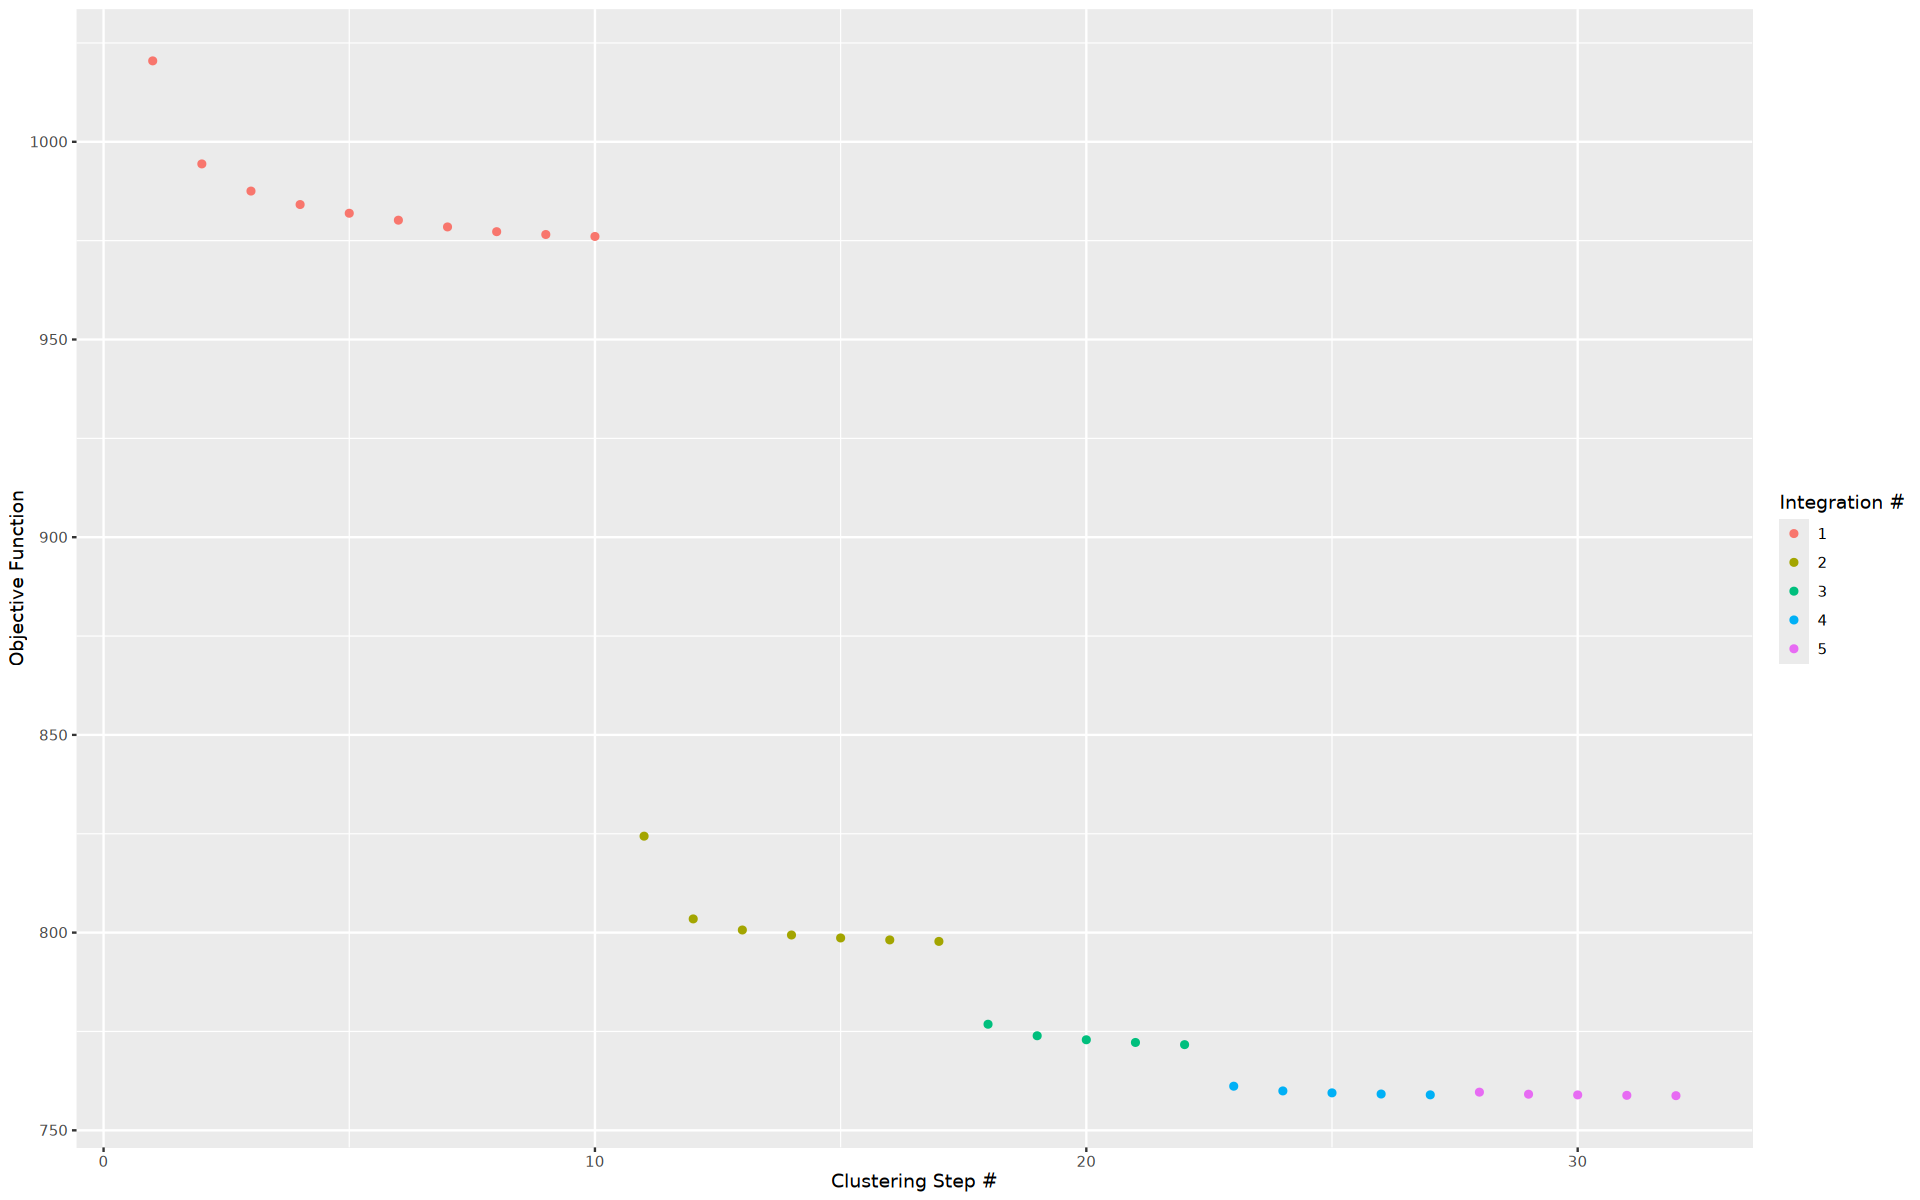

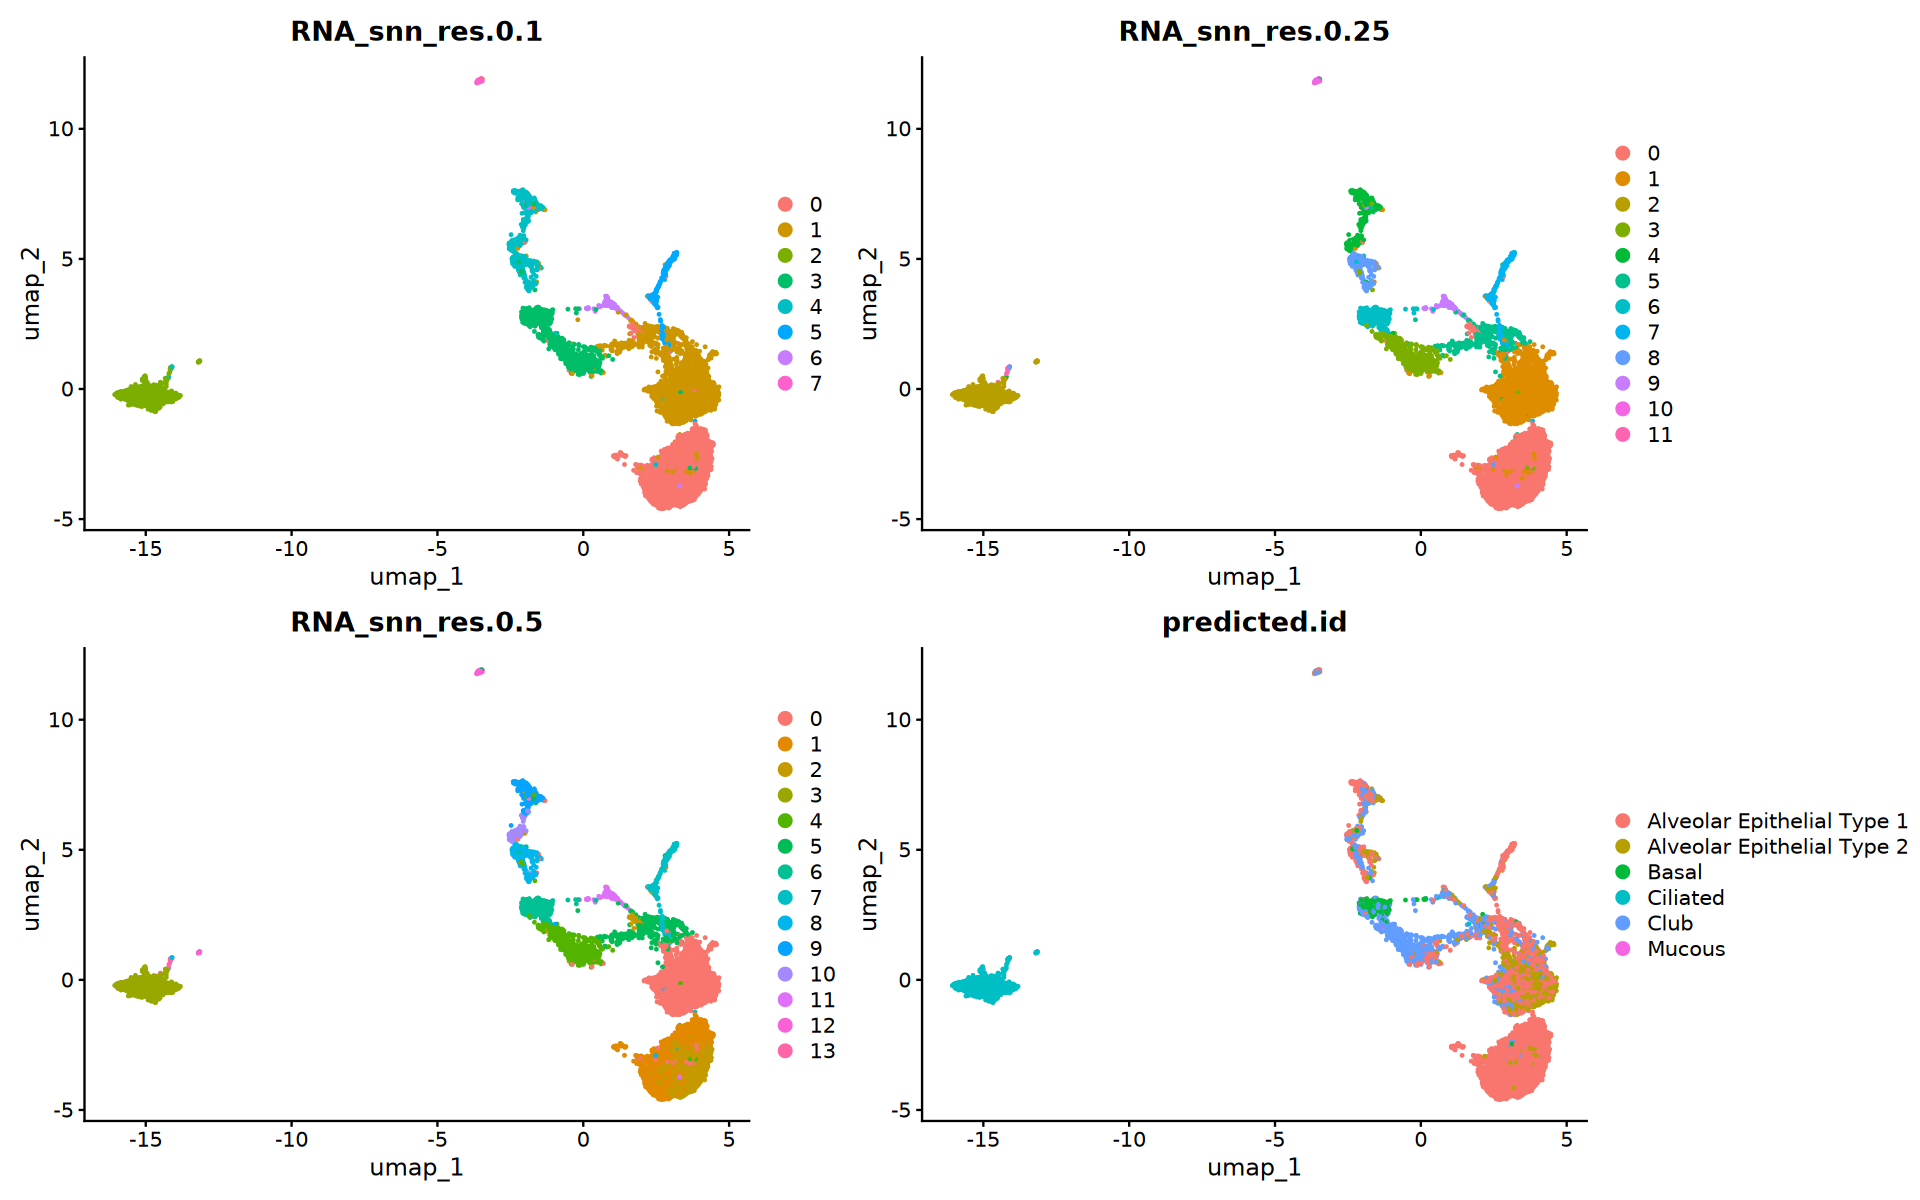

In [6]:
options(repr.plot.width = 16, repr.plot.height = 10)

se_epithelia <- Seurat::NormalizeData(se_epithelia, verbose = FALSE) %>%
    Seurat::FindVariableFeatures(selection.method = "vst", nfeatures = 3000) %>% 
    Seurat::ScaleData(verbose = FALSE) %>% 
    Seurat::RunPCA(pc.genes = .@var.genes, npcs = 50, verbose = FALSE)

se_epithelia <- se_epithelia %>% harmony::RunHarmony(object = ., group.by.vars = "donor", reduction.use = "pca", plot_convergence = TRUE, seed.use = 42)
se_epithelia <- se_epithelia %>% Seurat::RunUMAP(reduction = "harmony", dims = 1:30, n.components = 3, min.dist = 0.1, n.neighbors = 20, verbose = FALSE, seed.use = 42)

se_epithelia <- se_epithelia %>% Seurat::FindNeighbors(., reduction = "harmony", dims = 1:30) %>% 
    Seurat::FindClusters(., resolution = c(0.1, 0.25, 0.5))

Seurat::DimPlot(object = se_epithelia, reduction = "umap",
                group.by = c("RNA_snn_res.0.1","RNA_snn_res.0.25", "RNA_snn_res.0.5", "predicted.id"), 
                ncol = 2, label = FALSE)

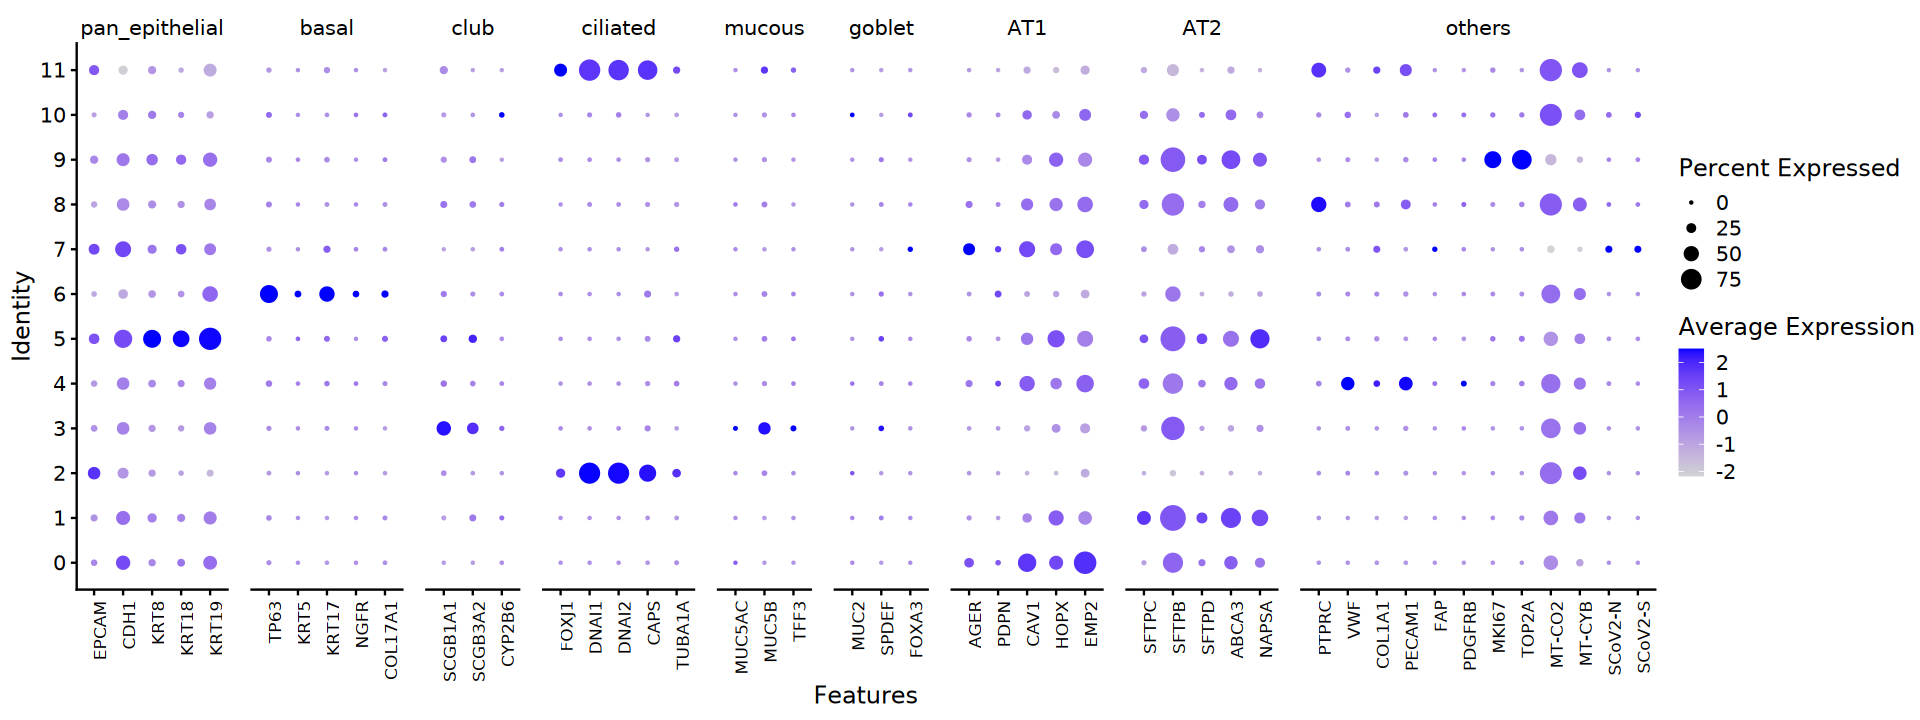

In [8]:
options(repr.plot.width = 16, repr.plot.height = 6)

epithelial_lineage <- list(
    pan_epithelial = c("EPCAM", "CDH1", "KRT8", "KRT18", "KRT19"),
    basal = c("TP63", "KRT5", "KRT17", "NGFR", "COL17A1"),
    club = c("SCGB1A1", "SCGB3A2", "CYP2B6"),
    ciliated = c("FOXJ1", "DNAI1", "DNAI2", "CAPS", "TUBA1A"),
    mucous = c("MUC5AC", "MUC5B", "TFF3"),
    goblet = c("MUC2", "SPDEF", "FOXA3"),
    AT1 = c("AGER", "PDPN", "CAV1", "HOPX", "EMP2"),
    AT2 = c("SFTPC", "SFTPB", "SFTPD", "ABCA3", "NAPSA"),  
    others = c("PTPRC", "VWF", "COL1A1",  "PECAM1", "FAP", "PDGFRB",
               "MKI67", "TOP2A", 
               "MT-CO2", "MT-CYB", 
                "SCoV2-N", "SCoV2-S"))

Seurat::DotPlot(object = se_epithelia,
                group.by = "RNA_snn_res.0.25",
                features = epithelial_lineage) +
        theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 10))

In [9]:
se_epithelia$annotation_lvl2 <- dplyr::case_when(
    se_epithelia$RNA_snn_res.0.25 %in% c("0", "7") ~ "AT1",
    se_epithelia$RNA_snn_res.0.25 %in% c("1", "5", "9") ~ "AT2",
    se_epithelia$RNA_snn_res.0.25 == "2" ~ "Ciliated cells",
    se_epithelia$RNA_snn_res.0.25 == "3" ~ "Club cells",
    se_epithelia$RNA_snn_res.0.25 == "6" ~ "Basal cells",
    se_epithelia$RNA_snn_res.0.25 %in% c("4", "8", "10", "11") ~ "LowQ (Epithelia)",
    TRUE ~ "WARNING"
)

se_epithelia$annotation_condition <- paste0(se_epithelia$annotation_lvl2, "-", se_epithelia$condition)
table(se_epithelia$annotation_lvl2)

se <- merge(se, y = se_epithelia)
se


             AT1              AT2      Basal cells   Ciliated cells 
            3824             2772              472             1199 
      Club cells LowQ (Epithelia) 
             626              988 

An object of class Seurat 
40720 features across 35625 samples within 2 assays 
Active assay: RNA (38720 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: integrated

In [10]:
meta_t <- "{annot_sc}/se_objects/se_lymphos/se-combined-tcells_annot_meta_woIntegration.rds" %>%
    glue::glue() %>%
    here::here() %>%
    readRDS(.)

meta_b <- "{annot_sc}/se_objects/se_lymphos/se-combined-Bcells&PCs_annot_meta_woIntegration.rds" %>%
    glue::glue() %>%
    here::here() %>%
    readRDS(.)

meta_tb <- bind_rows(meta_t, meta_b)

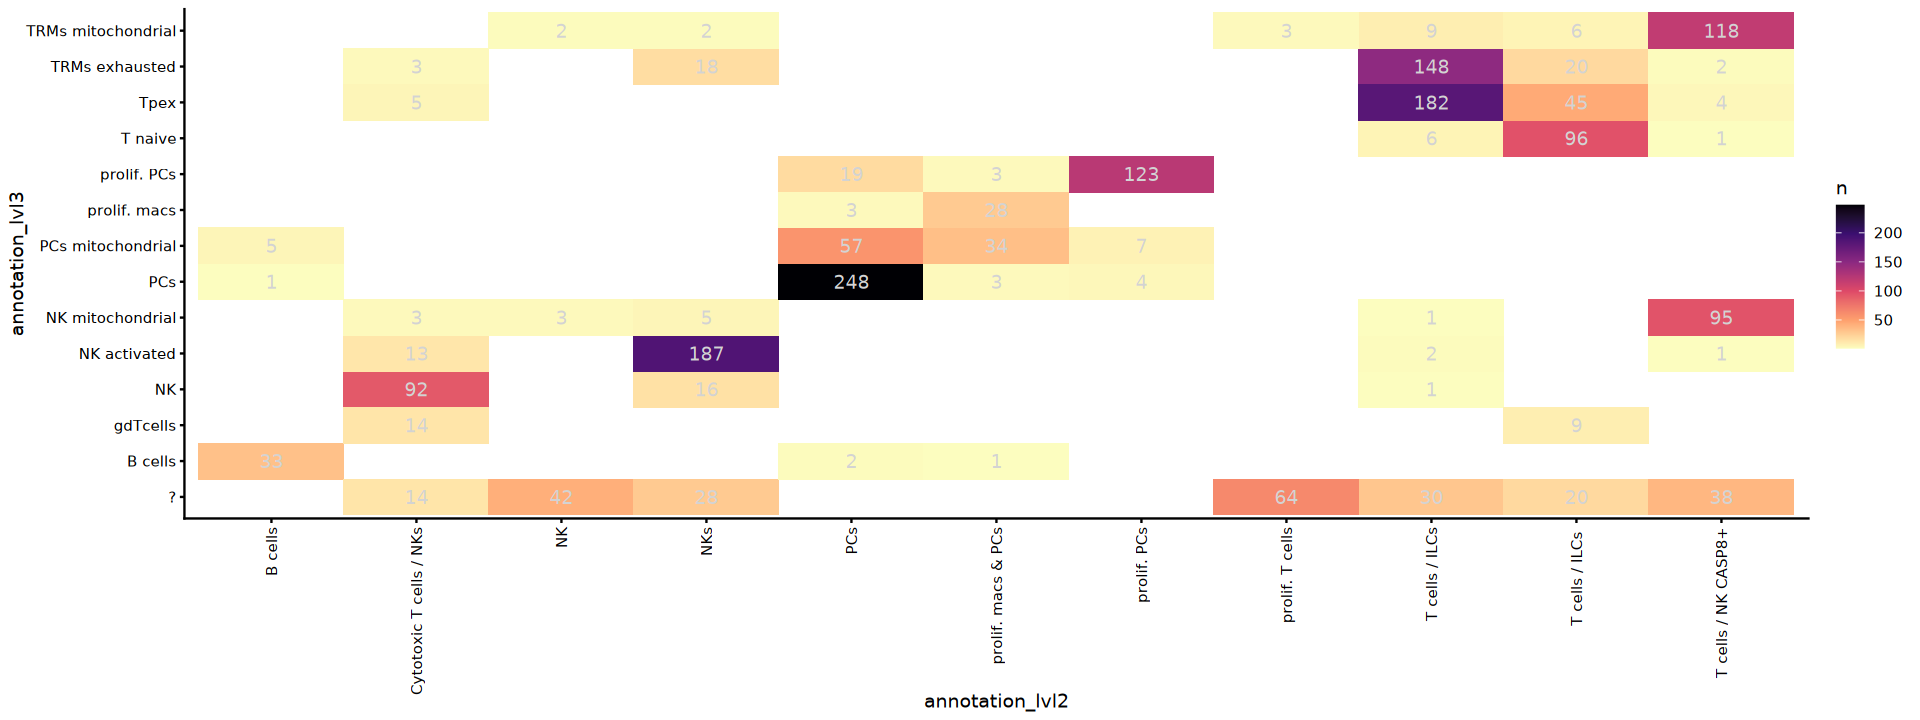

In [11]:
meta_tb %>%
    dplyr::count(annotation_lvl2, annotation_lvl3) %>%
    ggplot(aes(x = annotation_lvl2, y = annotation_lvl3, fill = n, label = n)) +
    geom_tile() +
    geom_text(color = "lightgrey") +
    scale_fill_viridis_c(option = "magma", direction = -1) + 
    theme_classic() +
    theme(axis.text.x = element_text(hjust = 1, vjust = 0.5, angle = 90))

In [12]:
tb_lvl3 <- meta_tb %>%
    tibble::rownames_to_column("bc") %>%
    dplyr::select(bc, annotation_lvl3) %>%
    mutate(bc = str_replace(bc, "^(acute|akut|chronic|control|prolonged)_", ""))

knitr::kable(table(tb_lvl3$annotation_lvl3))



|Var1               | Freq|
|:------------------|----:|
|?                  |  236|
|B cells            |   36|
|gdTcells           |   23|
|NK                 |  109|
|NK activated       |  203|
|NK mitochondrial   |  107|
|PCs                |  256|
|PCs mitochondrial  |  103|
|prolif. macs       |   31|
|prolif. PCs        |  145|
|T naive            |  103|
|Tpex               |  236|
|TRMs exhausted     |  191|
|TRMs mitochondrial |  140|

In [13]:
se@meta.data <- se@meta.data %>%
    tibble::rownames_to_column("bc") %>%
    left_join(tb_lvl3 %>% select(bc, annotation_lvl3), by = "bc") %>%
    mutate(annotation_lvl3 = case_when(
        is.na(annotation_lvl3) ~ annotation_lvl2,
        annotation_lvl3 == "?" ~ annotation_lvl2,
        TRUE ~ annotation_lvl3)) %>%
    tibble::column_to_rownames("bc")

## Reprocessing

Since we now have merged all the data we are going to re-process the data in order to capture the overall biological variability specific for this subset.

Re-normalize, scale and find new variable features specific for this subset:

In [14]:
se <- Seurat::NormalizeData(se, verbose = FALSE) %>%
    Seurat::FindVariableFeatures(selection.method = "vst", nfeatures = 3000) %>% 
    Seurat::ScaleData(verbose = FALSE) %>% 
    Seurat::RunPCA(pc.genes = .@var.genes, npcs = 50, verbose = FALSE)

# Exploration (R1)

In [15]:
dotplot <- function(grep_pattern, features, annot_col = "annotation_lvl3", use_order = FALSE, 
                    seurat_obj = se, show_condition_map = TRUE) {
    
    annotations <- sort(unique(seurat_obj@meta.data[[annot_col]]))
    filtered_annotations <- grep(grep_pattern, annotations, value = TRUE, ignore.case = TRUE, perl = TRUE)
    if (use_order) {
        filtered_annotations <- intersect(cell_type_order, filtered_annotations)
    } else {
        filtered_annotations <- sort(filtered_annotations)
    }
    cells_to_plot <- WhichCells(seurat_obj, expression = !!sym(annot_col) %in% filtered_annotations)
    subset_obj <- subset(seurat_obj, cells = cells_to_plot)
    
    if (show_condition_map) {
        condition_map <- subset_obj@meta.data %>%
            mutate(condition = sub('^.*-', '', annotation_condition)) %>%
            group_by(!!sym(annot_col)) %>%
            summarise(
                conditions = paste(unique(condition), collapse = ", "),
                n_cells = n(),
                .groups = 'drop'
            ) %>%
            mutate(label = paste0(!!sym(annot_col), " (", conditions, ", n=", n_cells, ")"))
        
        label_vec <- setNames(condition_map$label, condition_map[[annot_col]])
    } else {
        n_map <- subset_obj@meta.data %>%
            group_by(!!sym(annot_col)) %>%
            summarise(n_cells = n(), .groups = 'drop') %>%
            mutate(label = paste0(!!sym(annot_col), " (n=", n_cells, ")"))
        
        label_vec <- setNames(n_map$label, n_map[[annot_col]])
    }
    
    p <- DotPlot(subset_obj, features = features, group.by = annot_col, 
                 cluster.idents = !use_order, dot.scale = 8) +
        theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 10),
              axis.text.y = element_text(size = 10),
              plot.title = element_text(hjust = 0.5, size = 14, face = "bold")) +
        labs(y = "", x = "") +
        scale_y_discrete(labels = label_vec, limits = filtered_annotations) +
        scale_color_gradient2(low = "#313695", mid = "#FFFFBF", high = "#A50026", midpoint = 0)
    
    return(p)
}

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


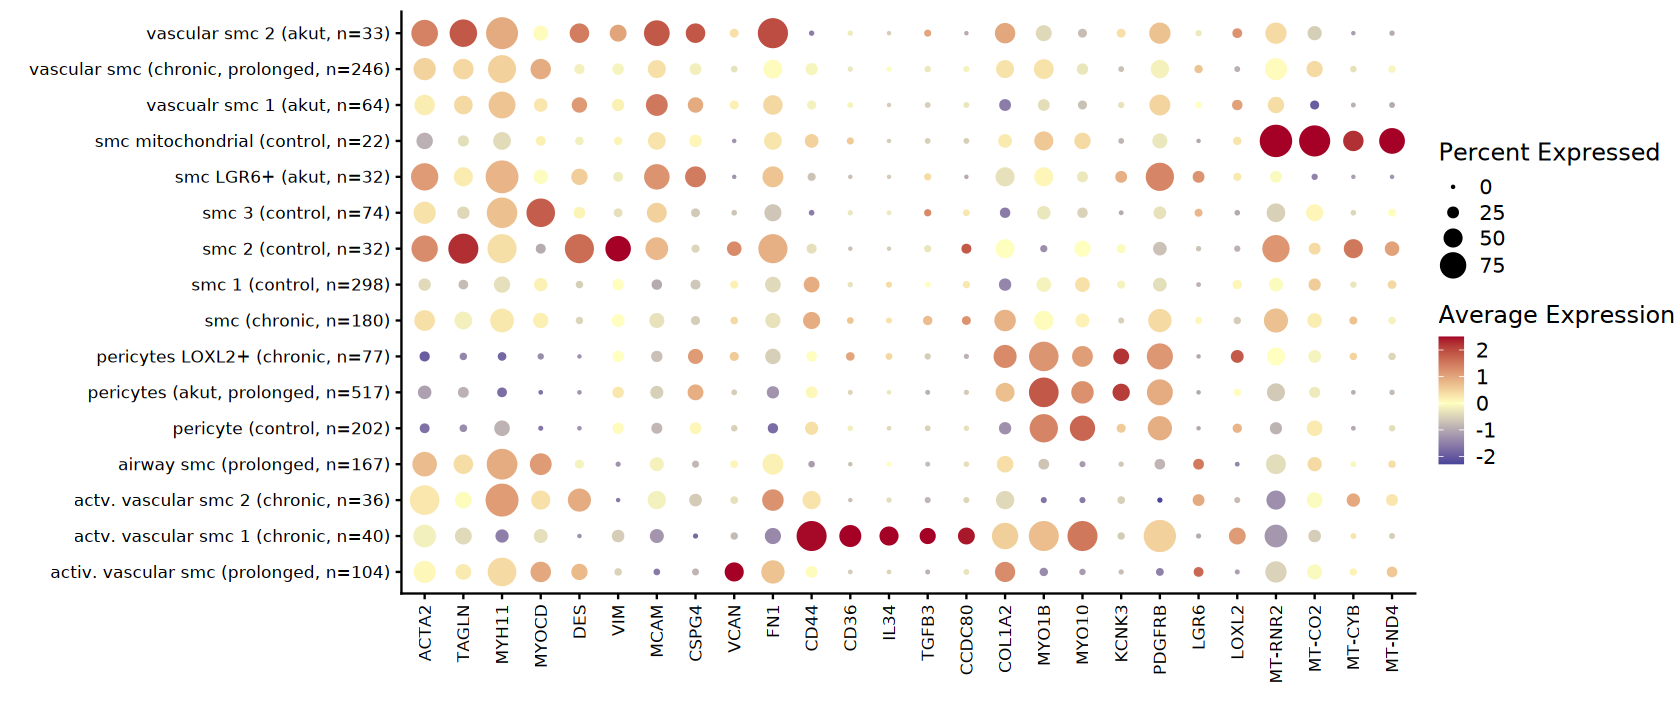

In [16]:
options(repr.plot.width = 14, repr.plot.height = 6)

dotplot("^(?!.*endo).*(smc|pericyte)", 
        c("ACTA2", "TAGLN", "MYH11", "MYOCD", "DES", "VIM", "MCAM", "CSPG4", # Smooth muscle 
          "VCAN", "FN1", "CD44", "CD36", "IL34", "TGFB3", "CCDC80", # activated
          "COL1A2", "MYO1B", "MYO10", "KCNK3", "PDGFRB", # Pericytes
          "LGR6", "LOXL2", "MT-RNR2", "MT-CO2", "MT-CYB", "MT-ND4"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


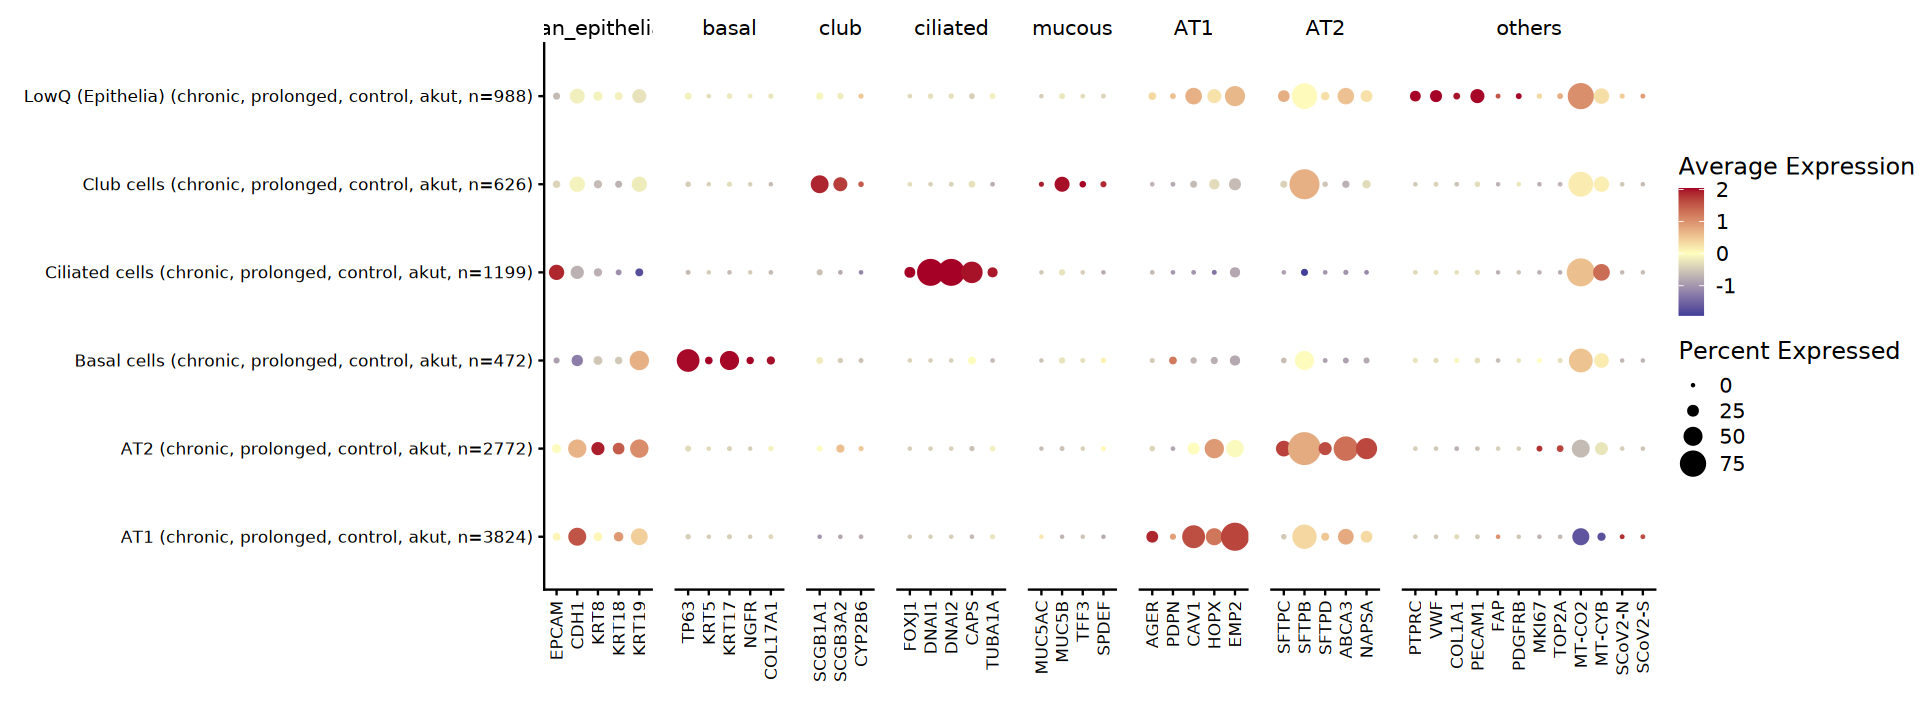

In [17]:
options(repr.plot.width = 16, repr.plot.height = 6)

dotplot("AT1|AT2|Club|Basal|Ciliated|LowQ",
        list(pan_epithelial = c("EPCAM", "CDH1", "KRT8", "KRT18", "KRT19"),
             basal = c("TP63", "KRT5", "KRT17", "NGFR", "COL17A1"),
             club = c("SCGB1A1", "SCGB3A2", "CYP2B6"),
             ciliated = c("FOXJ1", "DNAI1", "DNAI2", "CAPS", "TUBA1A"),
             mucous= c("MUC5AC", "MUC5B", "TFF3", "SPDEF"),
             AT1 = c("AGER", "PDPN", "CAV1", "HOPX", "EMP2"),
             AT2 = c("SFTPC", "SFTPB", "SFTPD", "ABCA3", "NAPSA"),
             others = c("PTPRC", "VWF", "COL1A1",  "PECAM1", "FAP", "PDGFRB",
                        "MKI67", "TOP2A", "MT-CO2", "MT-CYB","SCoV2-N", "SCoV2-S")))

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


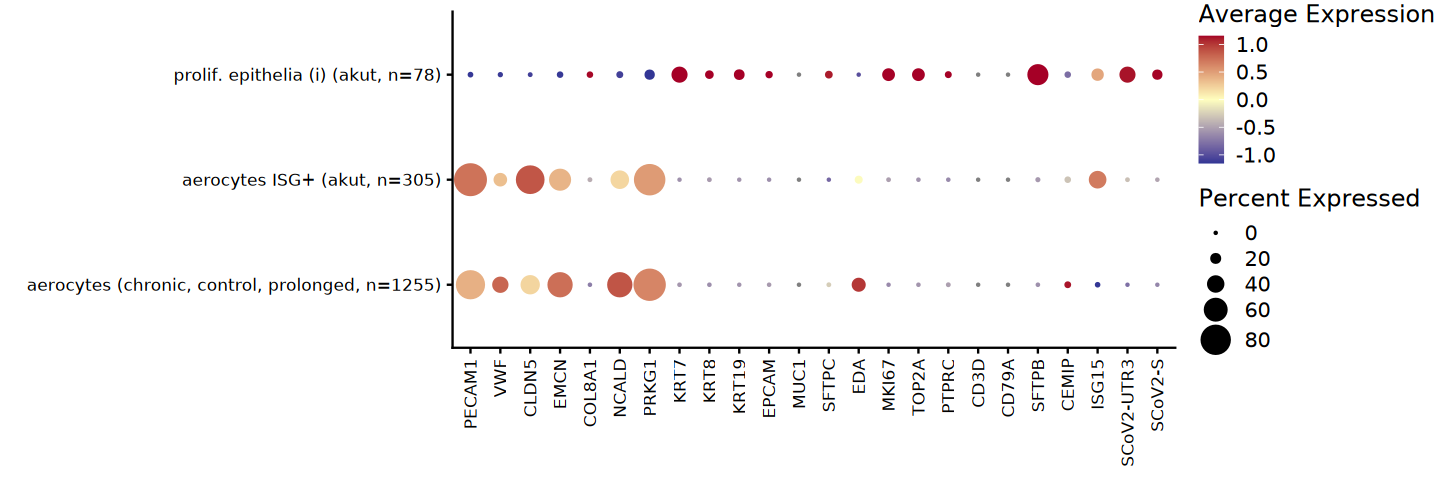

In [18]:
options(repr.plot.width = 12, repr.plot.height = 4.2)

dotplot("aerocytes|prolif. epithelia",
       c("PECAM1", "VWF", "CLDN5", "EMCN", "COL8A1", "NCALD", "PRKG1", # Aerocytes / ECs
         "KRT7", "KRT8", "KRT19", "EPCAM", "MUC1", "SFTPC", "EDA", # Epithelial
         "MKI67", "TOP2A", # Proliferation
         "PTPRC", "CD3D", "CD79A", # Immune
         "SFTPB", "CEMIP", "ISG15", "SCoV2-UTR3", "SCoV2-S"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


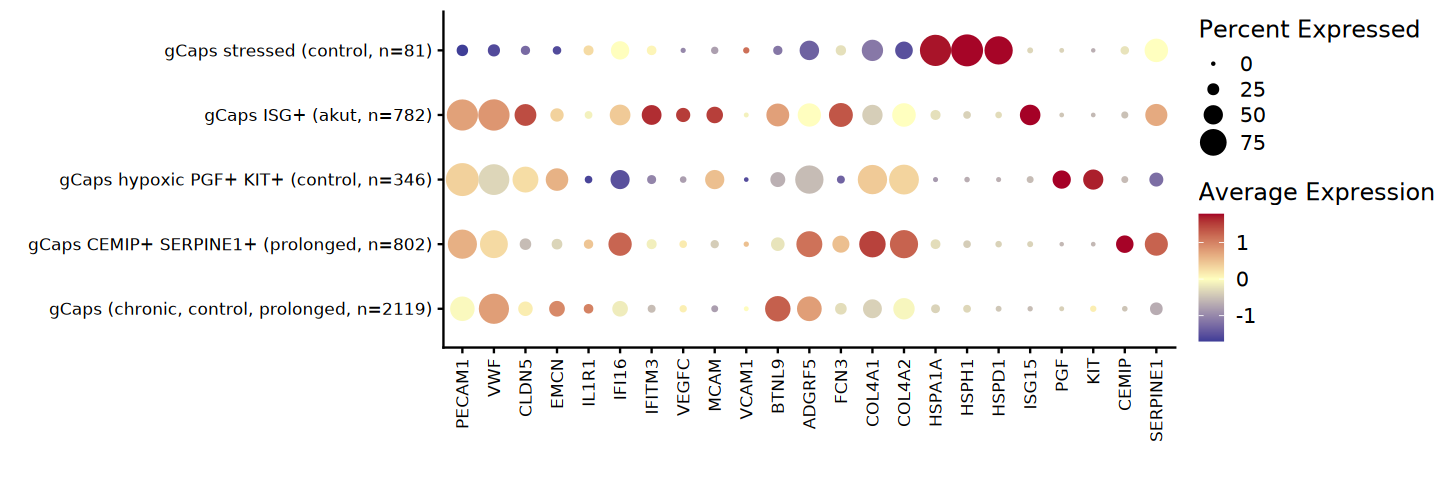

In [19]:
options(repr.plot.width = 12, repr.plot.height = 4)

dotplot("gCaps",
       c("PECAM1", "VWF", "CLDN5", "EMCN", # General endothelial / capillary 
         "IL1R1", "IFI16", "IFITM3","VEGFC", "MCAM", "VCAM1", # Activated
         "BTNL9",  "ADGRF5", "FCN3", "COL4A1", "COL4A2", # Capillary-specific
         "HSPA1A", "HSPH1", "HSPD1", # Stress
         "ISG15", "PGF", "KIT", "CEMIP", "SERPINE1"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


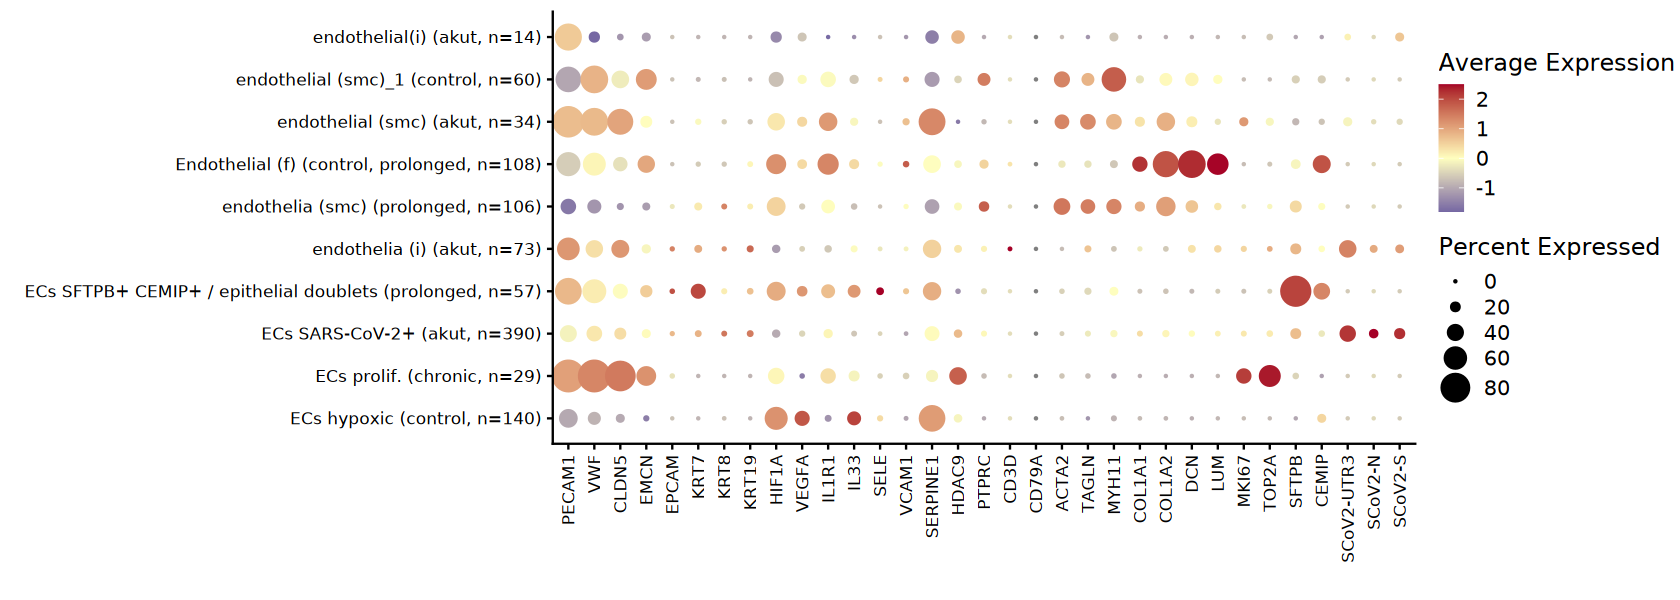

In [20]:
options(repr.plot.width = 14, repr.plot.height = 5) 

dotplot("^(?!.*(arterial|venous|lymphatic)).*(endo|ECs)",
       c("PECAM1", "VWF", "CLDN5", "EMCN", # Endothelial
         "EPCAM", "KRT7", "KRT8", "KRT19",  # Epithelial 
         "HIF1A", "VEGFA", # Hypoxic
         "IL1R1", "IL33", "SELE", "VCAM1", "SERPINE1", "HDAC9", # Activation / inflammatory 
         "PTPRC", "CD3D", "CD79A", # Immune
         "ACTA2", "TAGLN", "MYH11", # Smooth muscle
         "COL1A1", "COL1A2", "DCN", "LUM", # Fibro
         "MKI67", "TOP2A", # Proliferation
         "SFTPB", "CEMIP", "SCoV2-UTR3", "SCoV2-N", "SCoV2-S"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


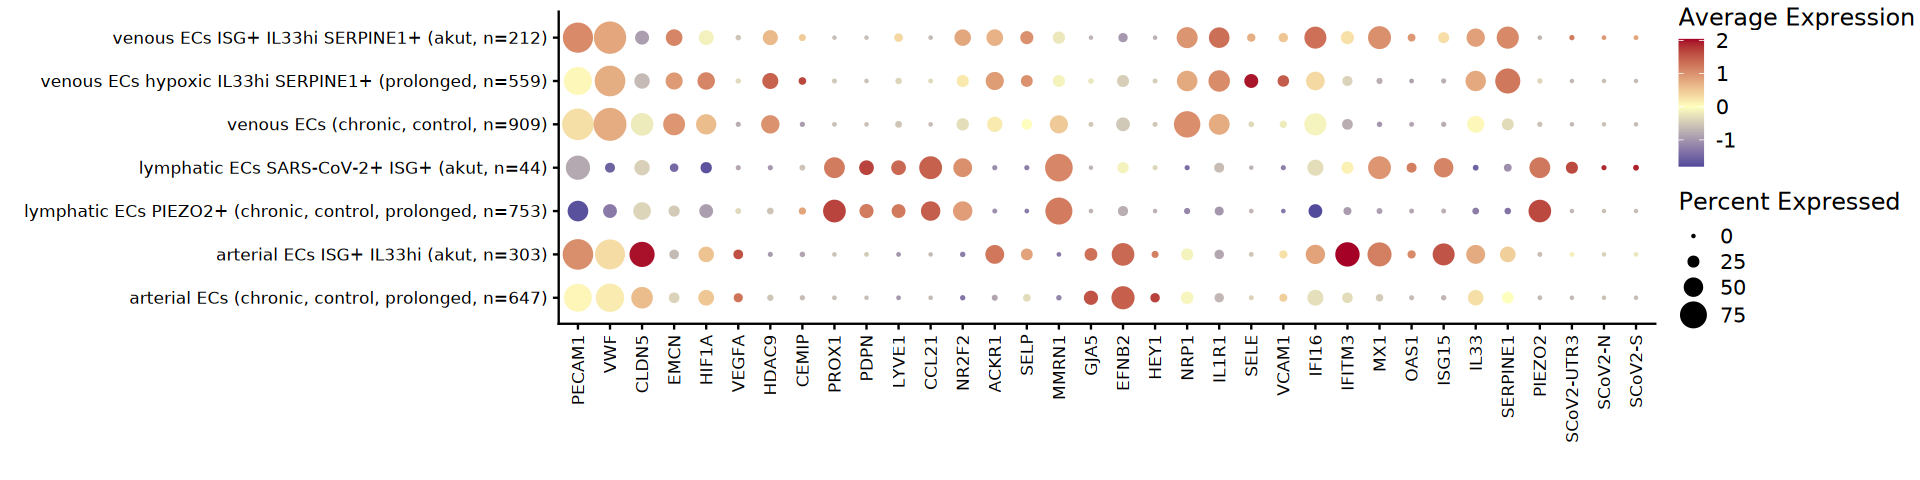

In [21]:
options(repr.plot.width = 16, repr.plot.height = 4)

dotplot("venous|arterial|lymphatic",
       c("PECAM1", "VWF", "CLDN5", "EMCN", # Pan-endothelial
         "HIF1A", "VEGFA", "HDAC9", "CEMIP", # Venous
         "PROX1", "PDPN", "LYVE1", "CCL21", # Lymphatic
         "NR2F2", "ACKR1", "SELP", "MMRN1", "GJA5", "EFNB2", "HEY1", "NRP1", # Arterial
         "IL1R1", "SELE", "VCAM1", # Activation
         "IFI16", "IFITM3", "MX1", "OAS1", # ISGs / antiviral
         "ISG15", "IL33", "SERPINE1", "PIEZO2", "SCoV2-UTR3", "SCoV2-N", "SCoV2-S"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


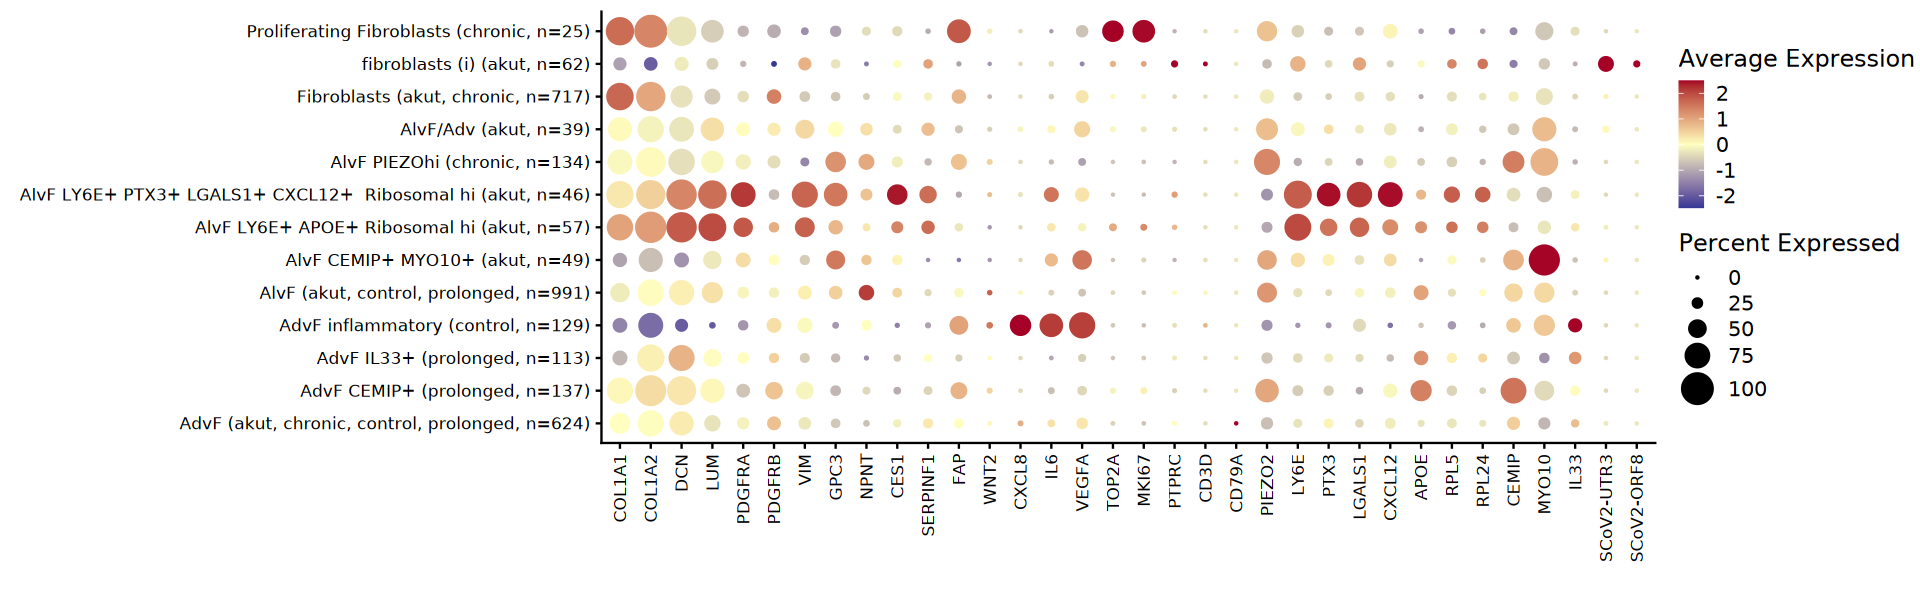

In [22]:
options(repr.plot.width = 16, repr.plot.height = 5)

dotplot("fibroblasts|Alv|Adv",
        c("COL1A1", "COL1A2", "DCN", "LUM", "PDGFRA", "PDGFRB", "VIM", # Stromal / fibroblast
          "GPC3", "NPNT", "CES1", # Alveolar 
          "SERPINF1", "FAP", "WNT2", # Advential
          "CXCL8", "IL6", "VEGFA", # Inflammatory
          "TOP2A", "MKI67", # Proliferation
          "PTPRC", "CD3D", "CD79A", # Immune
          "PIEZO2", "LY6E", "PTX3", "LGALS1", "CXCL12", "APOE","RPL5", 
          "RPL24", "CEMIP", "MYO10", "IL33", "SCoV2-UTR3", "SCoV2-ORF8"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


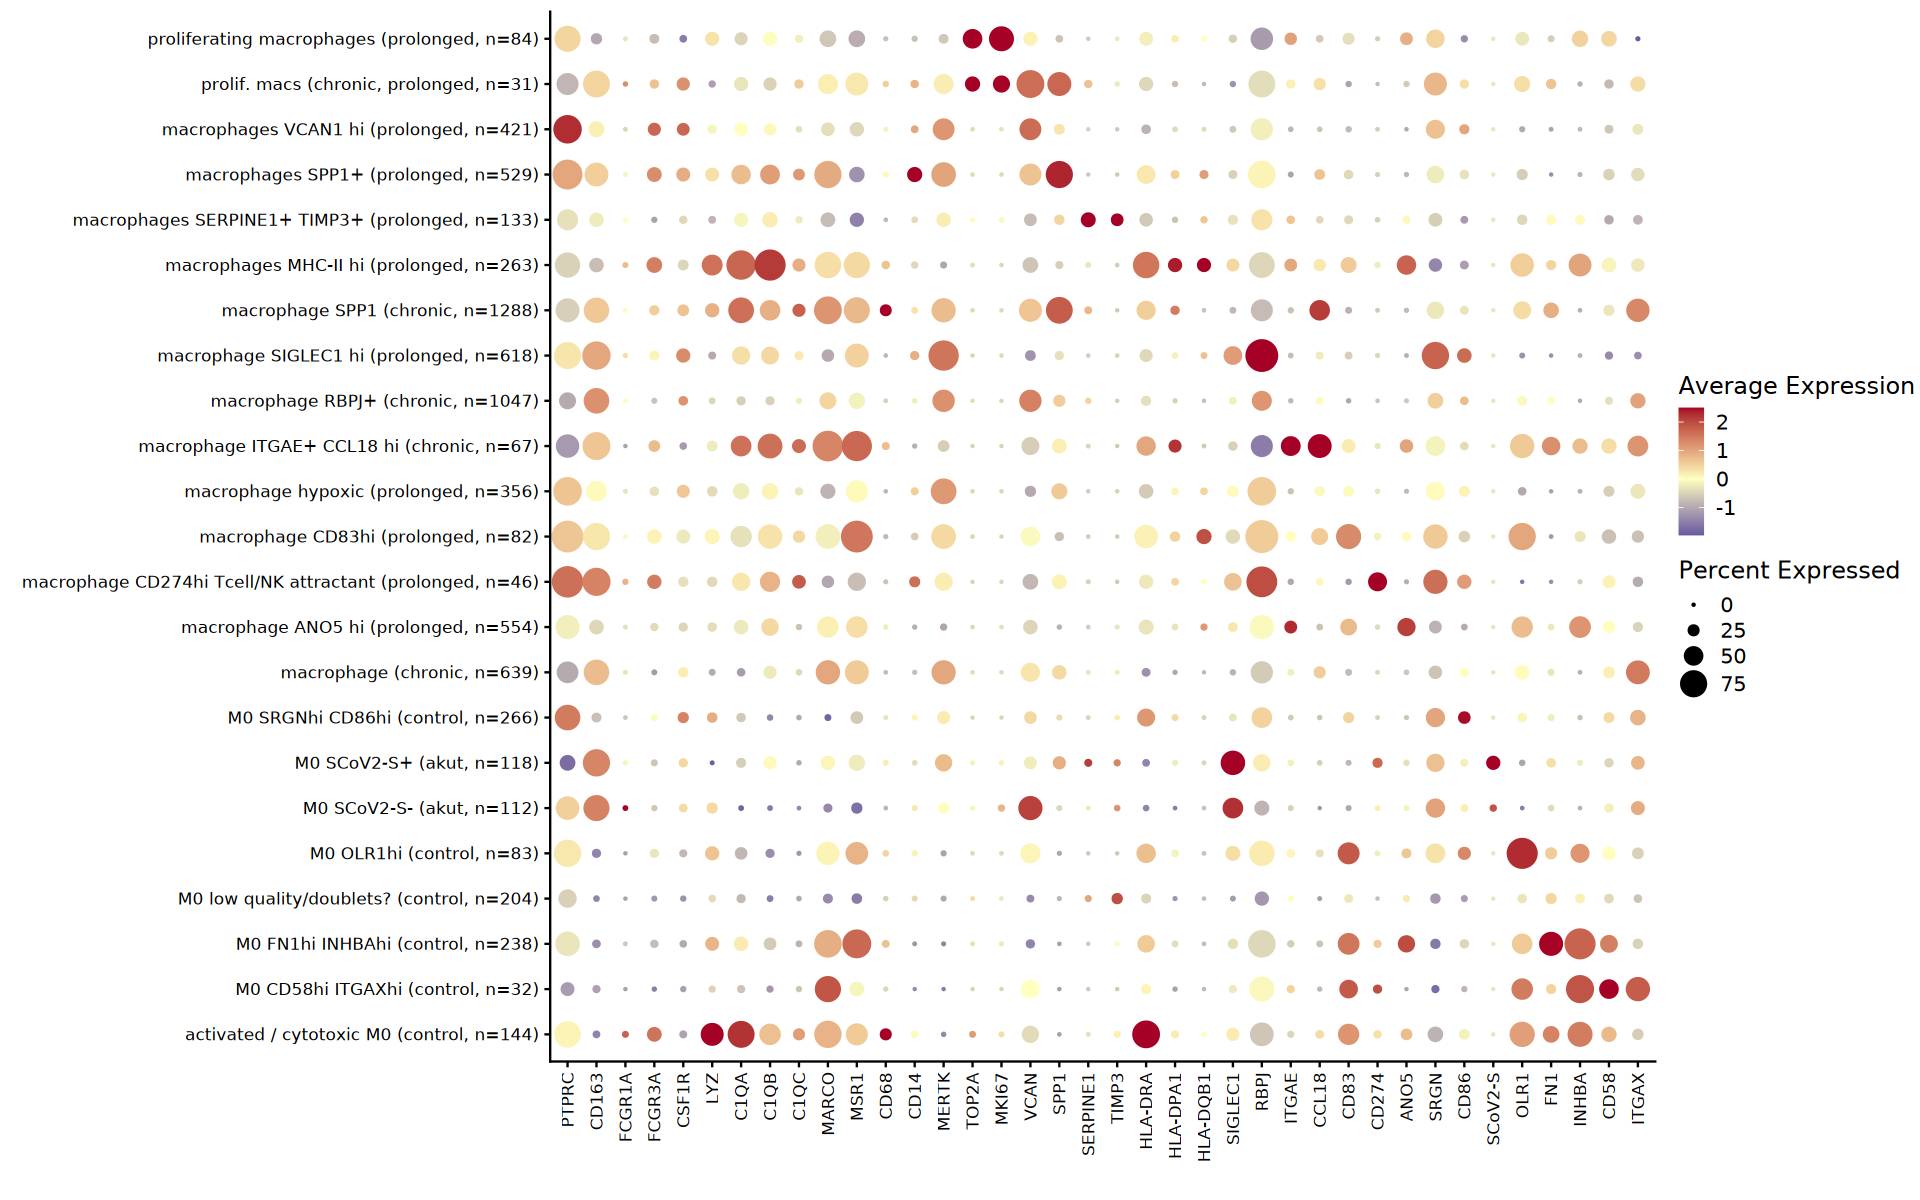

In [23]:
options(repr.plot.width = 16, repr.plot.height = 10)

dotplot("mac|M0",
        c("PTPRC", "CD163", "FCGR1A", "FCGR3A", "CSF1R", "LYZ", "C1QA", 
          "C1QB", "C1QC", "MARCO", "MSR1", "CD68", "CD14", "MERTK", # m0
          "TOP2A", "MKI67", # Proliferation
          "VCAN", "SPP1", "SERPINE1", "TIMP3", "HLA-DRA", "HLA-DPA1", "HLA-DQB1", "SIGLEC1", 
          "RBPJ", "ITGAE", "CCL18", "CD83", "CD274", "ANO5", "SRGN", "CD86", "SCoV2-S", 
          "OLR1", "FN1", "INHBA", "CD58", "ITGAX"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


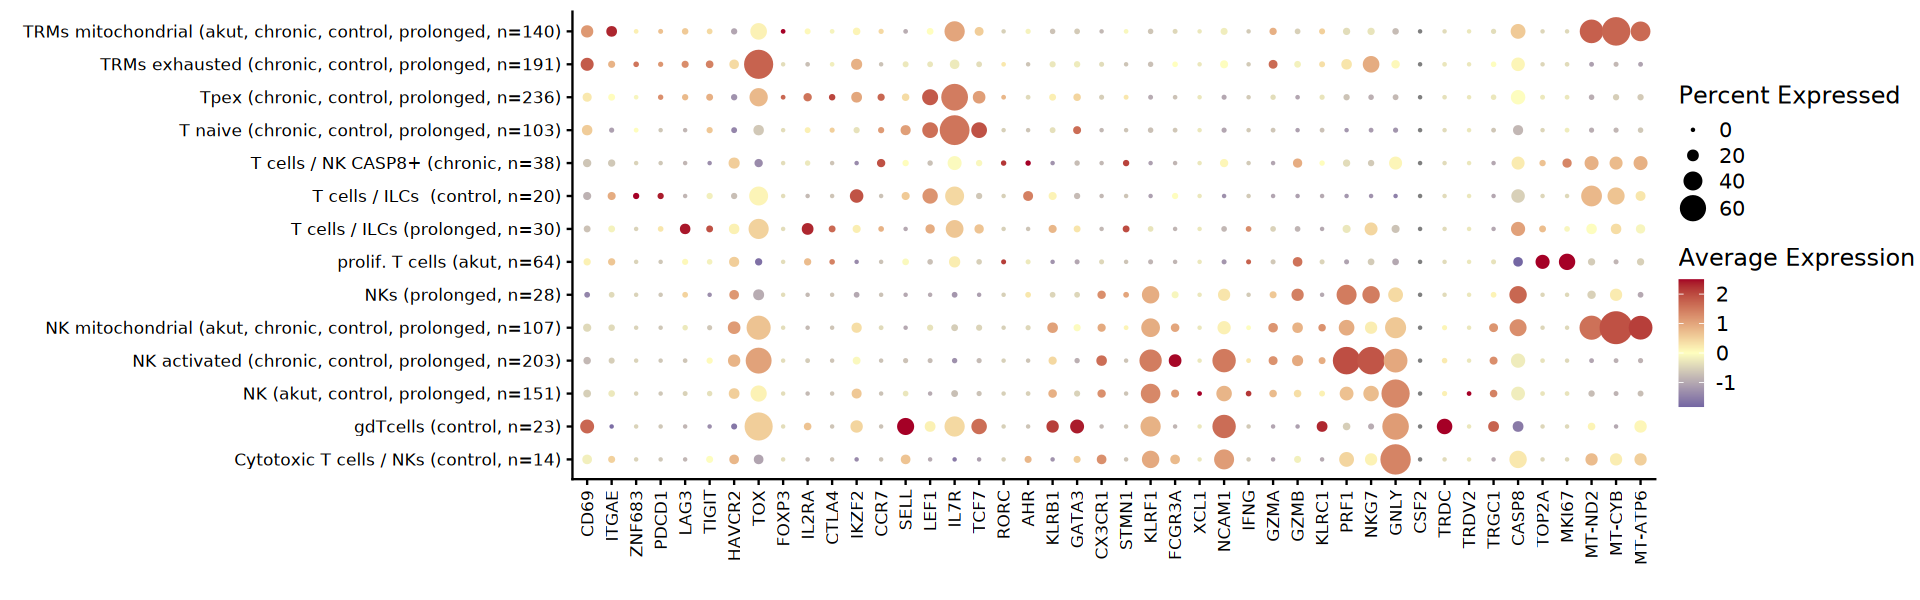

In [24]:
options(repr.plot.width = 16, repr.plot.height = 5)

dotplot("^(?!.*(macrophage|mast)).*(T[ ]?cells|Cytotoxic T|NK|Tpex|gdTcells|T naive|TRMs)",
       c("CD69", "ITGAE", "ZNF683", # TRMs mitochondrial
         "PDCD1", "LAG3", "TIGIT", "HAVCR2", "TOX", # TRMs exhausted
         "FOXP3", "IL2RA", "CTLA4", "IKZF2",  # Tregs
         "CCR7", "SELL", "LEF1", "IL7R", "TCF7", # T naive
         "RORC", "AHR", "KLRB1", "GATA3", "CX3CR1", # T cells/ILCs 
         "STMN1",  # T cells prolif. 
         "KLRF1", "FCGR3A", "XCL1", "NCAM1", "IFNG", "GZMA", 
         "GZMB", "KLRC1", "PRF1", "NKG7", "GNLY", "CSF2", # NK
         "TRDC", "TRDV2", "TRGC1", # gdT 
         "CASP8", "TOP2A", "MKI67", "MT-ND2", "MT-CYB", "MT-ATP6"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


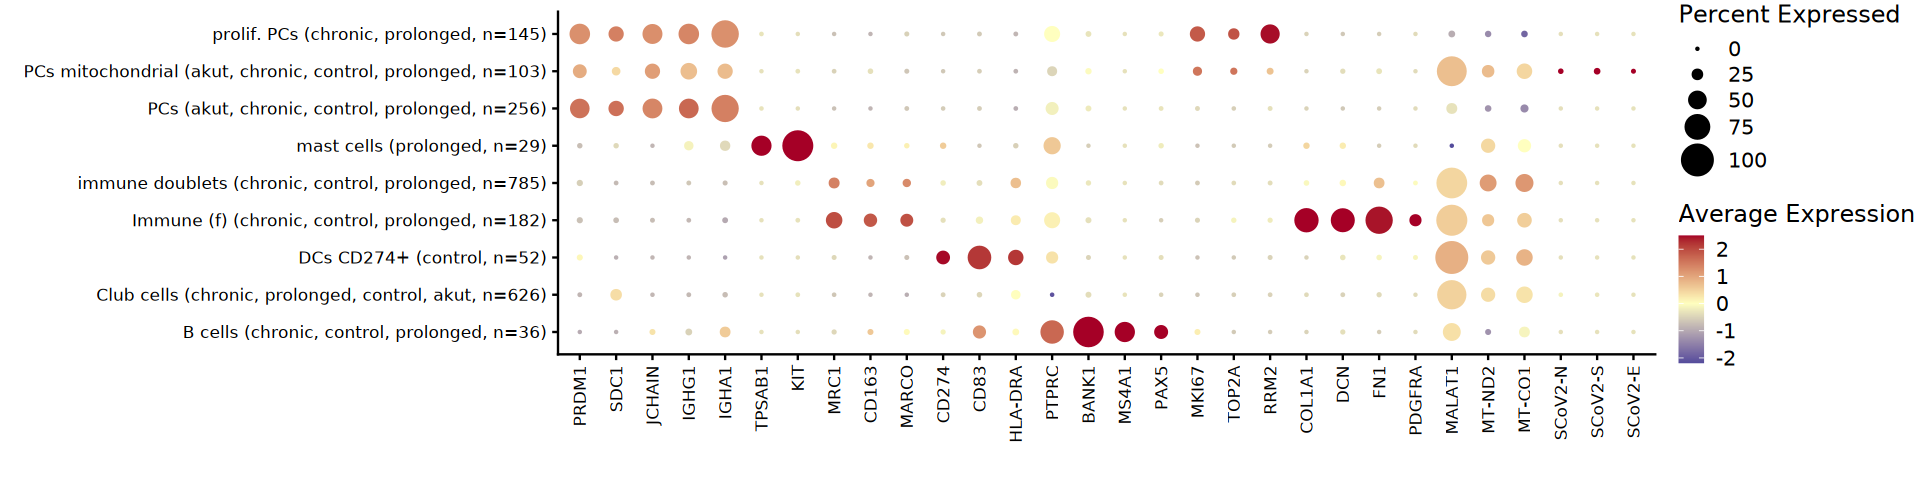

In [25]:
options(repr.plot.width = 16, repr.plot.height = 4) 

dotplot("PCs|DCs|B cells|mast|immune",
       c("PRDM1","SDC1","JCHAIN","IGHG1","IGHA1", # PCs
         "TPSAB1","KIT", # mast
         "MRC1","CD163","MARCO", "CD274","CD83","HLA-DRA",# m0 / DC
         "PTPRC","BANK1","MS4A1","PAX5", # B cells
         "MKI67","TOP2A","RRM2", # Proliferation
         "COL1A1", "DCN", "FN1", "PDGFRA", # Fibro
         "MALAT1","MT-ND2","MT-CO1", 
         "SCoV2-N","SCoV2-S","SCoV2-E"))

## Name standarization

In [26]:
se@meta.data <- se@meta.data %>% 
    mutate(
        annotation_lvl4 = case_when(
            grepl("pericyte", annotation_lvl3, ignore.case = TRUE) ~ "Pericytes",
            grepl("^smc mito", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "LowQ (SMC)",
            grepl("^(?!.*(endo|mito|actv.*?1)).*?(smc|airway)", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "SMC",
            grepl("actv.*? 1", annotation_lvl3, ignore.case = TRUE) ~ "Activated vascular SMC / Pericytes", 
            grepl("^(?!.*(alveolar)).*?(epithelial)", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "Doublets (epithelia-endothelia)", 

            grepl("^(?!.*(lymphatic)).*?(ECs SARS)|endothelia \\(i\\)", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "ECs (SARS-CoV-2+)",
            grepl("^(?!.*(arterial|lymphatic|epi|endothelia \\(i\\)|endothelia \\(smc\\)|SARS)).*?(^EC|endo)", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "ECs",
            grepl("endothelia \\(smc\\)", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "ECs (SMC)",

            grepl("venous", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "Venous ECs",
            grepl("lymphatic", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "Lymphatic ECs",
            grepl("arterial", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "Arterial ECs",

            grepl("Proliferating Fibro", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "Proliferating Fibroblasts",
            grepl("fibroblasts \\(i\\)", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "Fibroblasts (i)",
            grepl("^Fibroblasts", annotation_lvl3, ignore.case = FALSE, perl = TRUE) ~ "Fibroblasts", 
            grepl("AlvF/Adv", annotation_lvl3, ignore.case = FALSE, perl = TRUE) ~ "AlvF/AdvF", 
            grepl("AlvF.*CEMIP.*MYO10", annotation_lvl3, ignore.case = FALSE, perl = TRUE) ~ "AlvF CEMIP+ MYO10+", 
            grepl("AdvF.*inflammatory", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "AdvF inflammatory",

            grepl("^(?!.*(Adv|MYO10)).*AlvF", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "AlvF",
            grepl("^(?!.*(Alv|inflammatory)).*AdvF", annotation_lvl3, ignore.case = TRUE, perl = TRUE) ~ "AdvF",
        TRUE ~ annotation_lvl3
        )
    )

# Exploration (R2)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


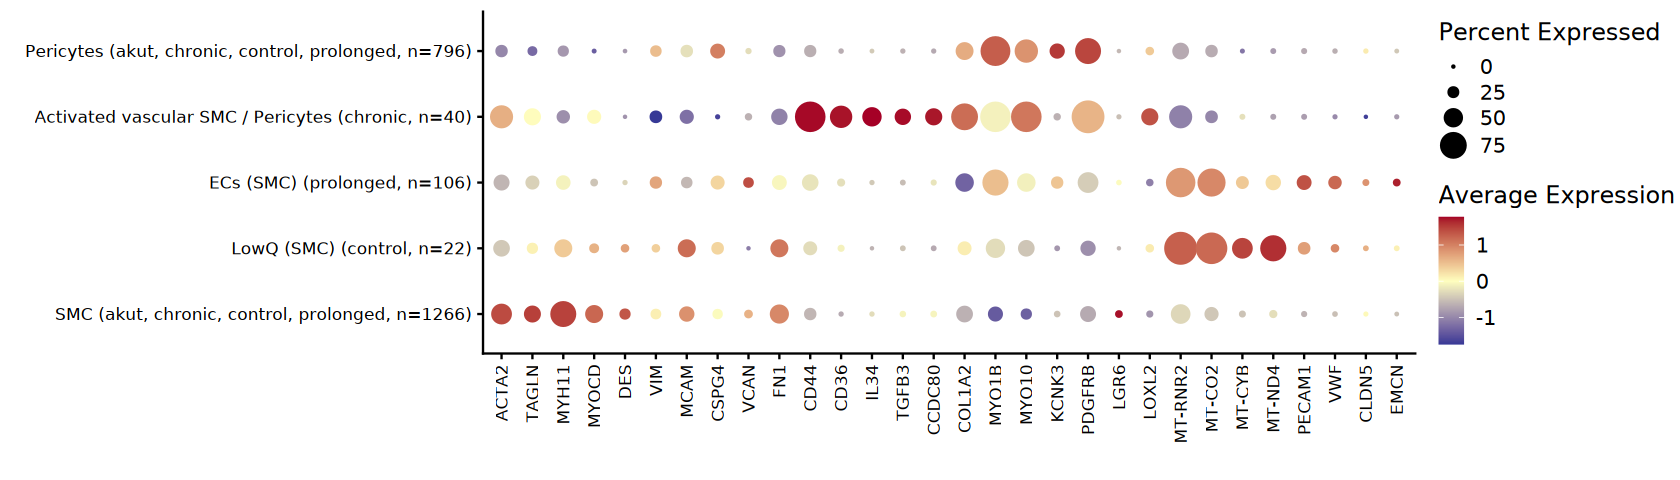

In [27]:
options(repr.plot.width = 14, repr.plot.height = 4)

cell_type_order <- c("SMC", "LowQ (SMC)", "ECs (SMC)", "Activated vascular SMC / Pericytes", "Pericytes")
dotplot("SMC|Pericyte", annot_col = "annotation_lvl4", use_order = TRUE,
        c("ACTA2", "TAGLN", "MYH11", "MYOCD", "DES", "VIM", "MCAM", "CSPG4", # Smooth muscle 
          "VCAN", "FN1", "CD44", "CD36", "IL34", "TGFB3", "CCDC80", # activated
          "COL1A2", "MYO1B", "MYO10", "KCNK3", "PDGFRB", # Pericytes
          "LGR6", "LOXL2", "MT-RNR2", "MT-CO2", "MT-CYB", "MT-ND4",
          "PECAM1", "VWF", "CLDN5", "EMCN")) # Endothelial

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


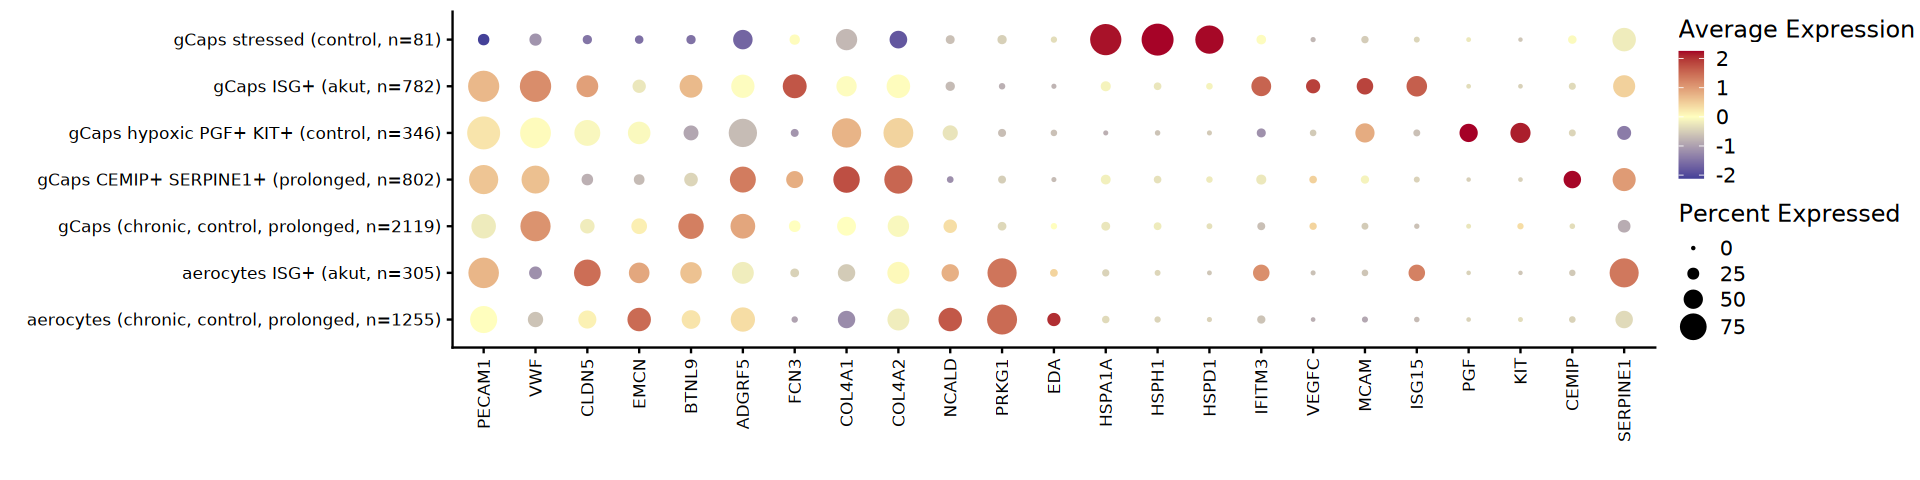

In [28]:
options(repr.plot.width = 16, repr.plot.height = 4)

dotplot("gCaps|aerocytes", annot_col = "annotation_lvl4", use_order = FALSE,
       c("PECAM1", "VWF", "CLDN5", "EMCN", # ECs
         "BTNL9",  "ADGRF5", "FCN3", "COL4A1", "COL4A2", # Capillary
         "NCALD","PRKG1", "EDA", # aerocytes
         "HSPA1A", "HSPH1", "HSPD1", # Stress
         "IFITM3","VEGFC", "MCAM", # Activated
         "ISG15", "PGF", "KIT", "CEMIP", "SERPINE1"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


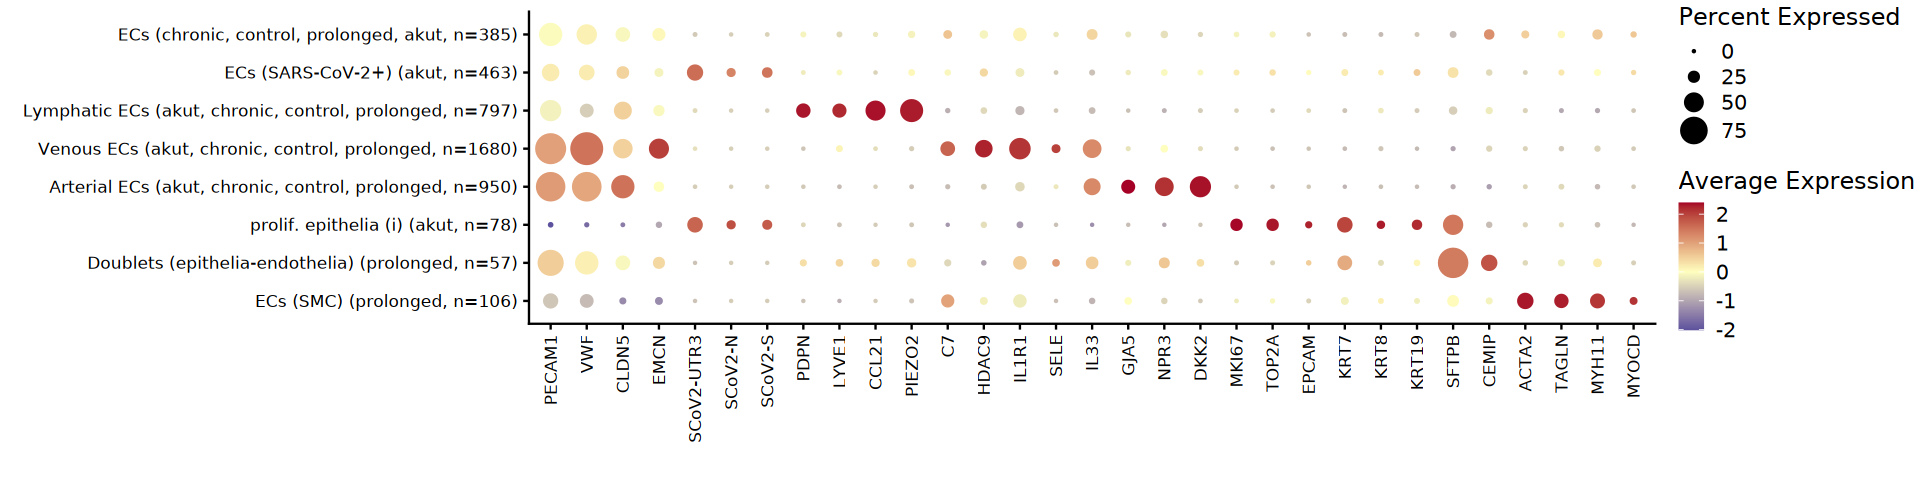

In [29]:
options(repr.plot.width = 16, repr.plot.height = 4)

cell_type_order <- c("ECs (SMC)", "Doublets (epithelia-endothelia)", "prolif. epithelia (i)",
                    "Arterial ECs", "Venous ECs", "Lymphatic ECs", "ECs (SARS-CoV-2+)", "ECs")
dotplot("epith|endo|ECs", annot_col = "annotation_lvl4", use_order = TRUE,
       c("PECAM1", "VWF", "CLDN5", "EMCN", # ECs
         "SCoV2-UTR3", "SCoV2-N", "SCoV2-S",
         "PDPN", "LYVE1", "CCL21", "PIEZO2", # Lymphatic
         "C7", "HDAC9", "IL1R1", "SELE", "IL33", # Venous
         "GJA5", "NPR3", "DKK2", # Arterial 
         "MKI67", "TOP2A", # Proliferation
         "EPCAM", "KRT7", "KRT8", "KRT19", # Epithelial
         "SFTPB", "CEMIP",
         "ACTA2", "TAGLN", "MYH11", "MYOCD")) # Smooth muscle

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


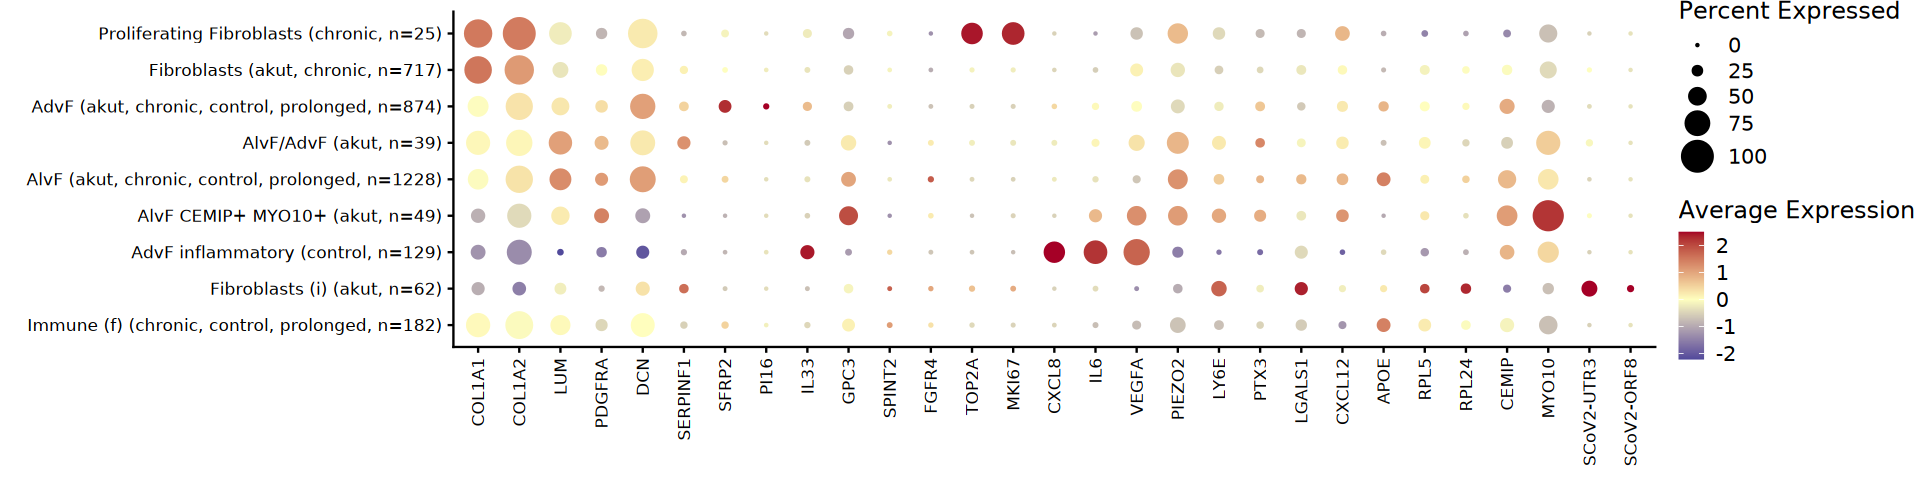

In [30]:
options(repr.plot.width = 16, repr.plot.height = 4.2)

cell_type_order <- c("Immune (f)", "Fibroblasts (i)", "AdvF inflammatory",
                     "AlvF CEMIP+ MYO10+", "AlvF", "AlvF/AdvF", "AdvF", 
                     "Fibroblasts", "Proliferating Fibroblasts")
dotplot("fibroblasts|Alv|Adv|Immune \\(f\\)", annot_col = "annotation_lvl4", use_order = TRUE,
        c("COL1A1", "COL1A2", "LUM", "PDGFRA",  # gen
          "DCN", "SERPINF1", "SFRP2", "PI16", "IL33", # Advential
          "GPC3", "SPINT2", "FGFR4", # Alveolar
          "TOP2A", "MKI67", # Proliferation
          "CXCL8", "IL6", "VEGFA", # Inflammatory
          "PIEZO2", "LY6E", "PTX3", "LGALS1", "CXCL12", "APOE", "RPL5", 
          "RPL24", "CEMIP", "MYO10", "SCoV2-UTR3", "SCoV2-ORF8"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


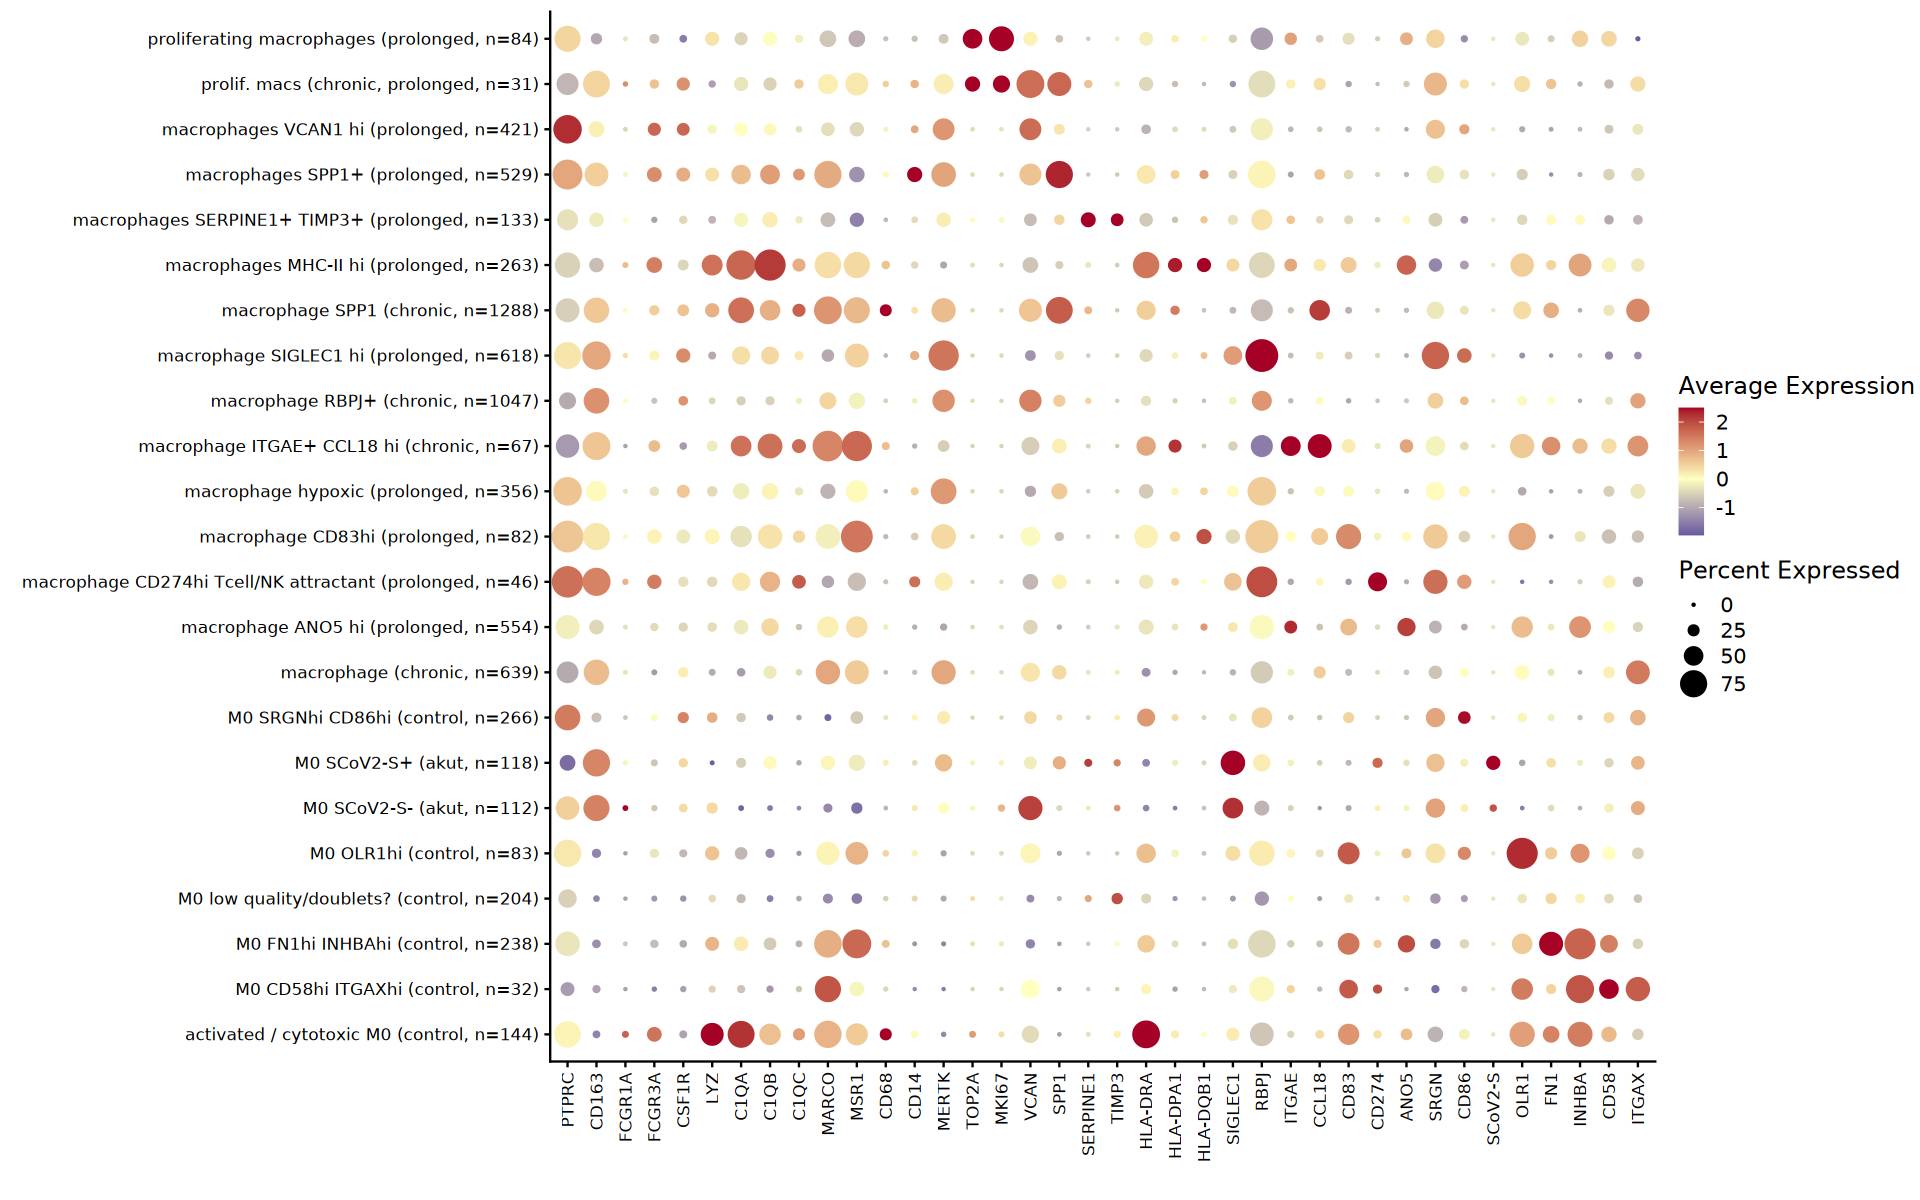

In [31]:
options(repr.plot.width = 16, repr.plot.height = 10)

dotplot("mac|M0", annot_col = "annotation_lvl4", 
        c("PTPRC", "CD163", "FCGR1A", "FCGR3A", "CSF1R", "LYZ", "C1QA", 
          "C1QB", "C1QC", "MARCO", "MSR1", "CD68", "CD14", "MERTK", # m0
          "TOP2A", "MKI67", # Proliferation
          "VCAN", "SPP1", "SERPINE1", "TIMP3", "HLA-DRA", "HLA-DPA1", "HLA-DQB1", "SIGLEC1", 
          "RBPJ", "ITGAE", "CCL18", "CD83", "CD274", "ANO5", "SRGN", "CD86", "SCoV2-S", 
          "OLR1", "FN1", "INHBA", "CD58", "ITGAX"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


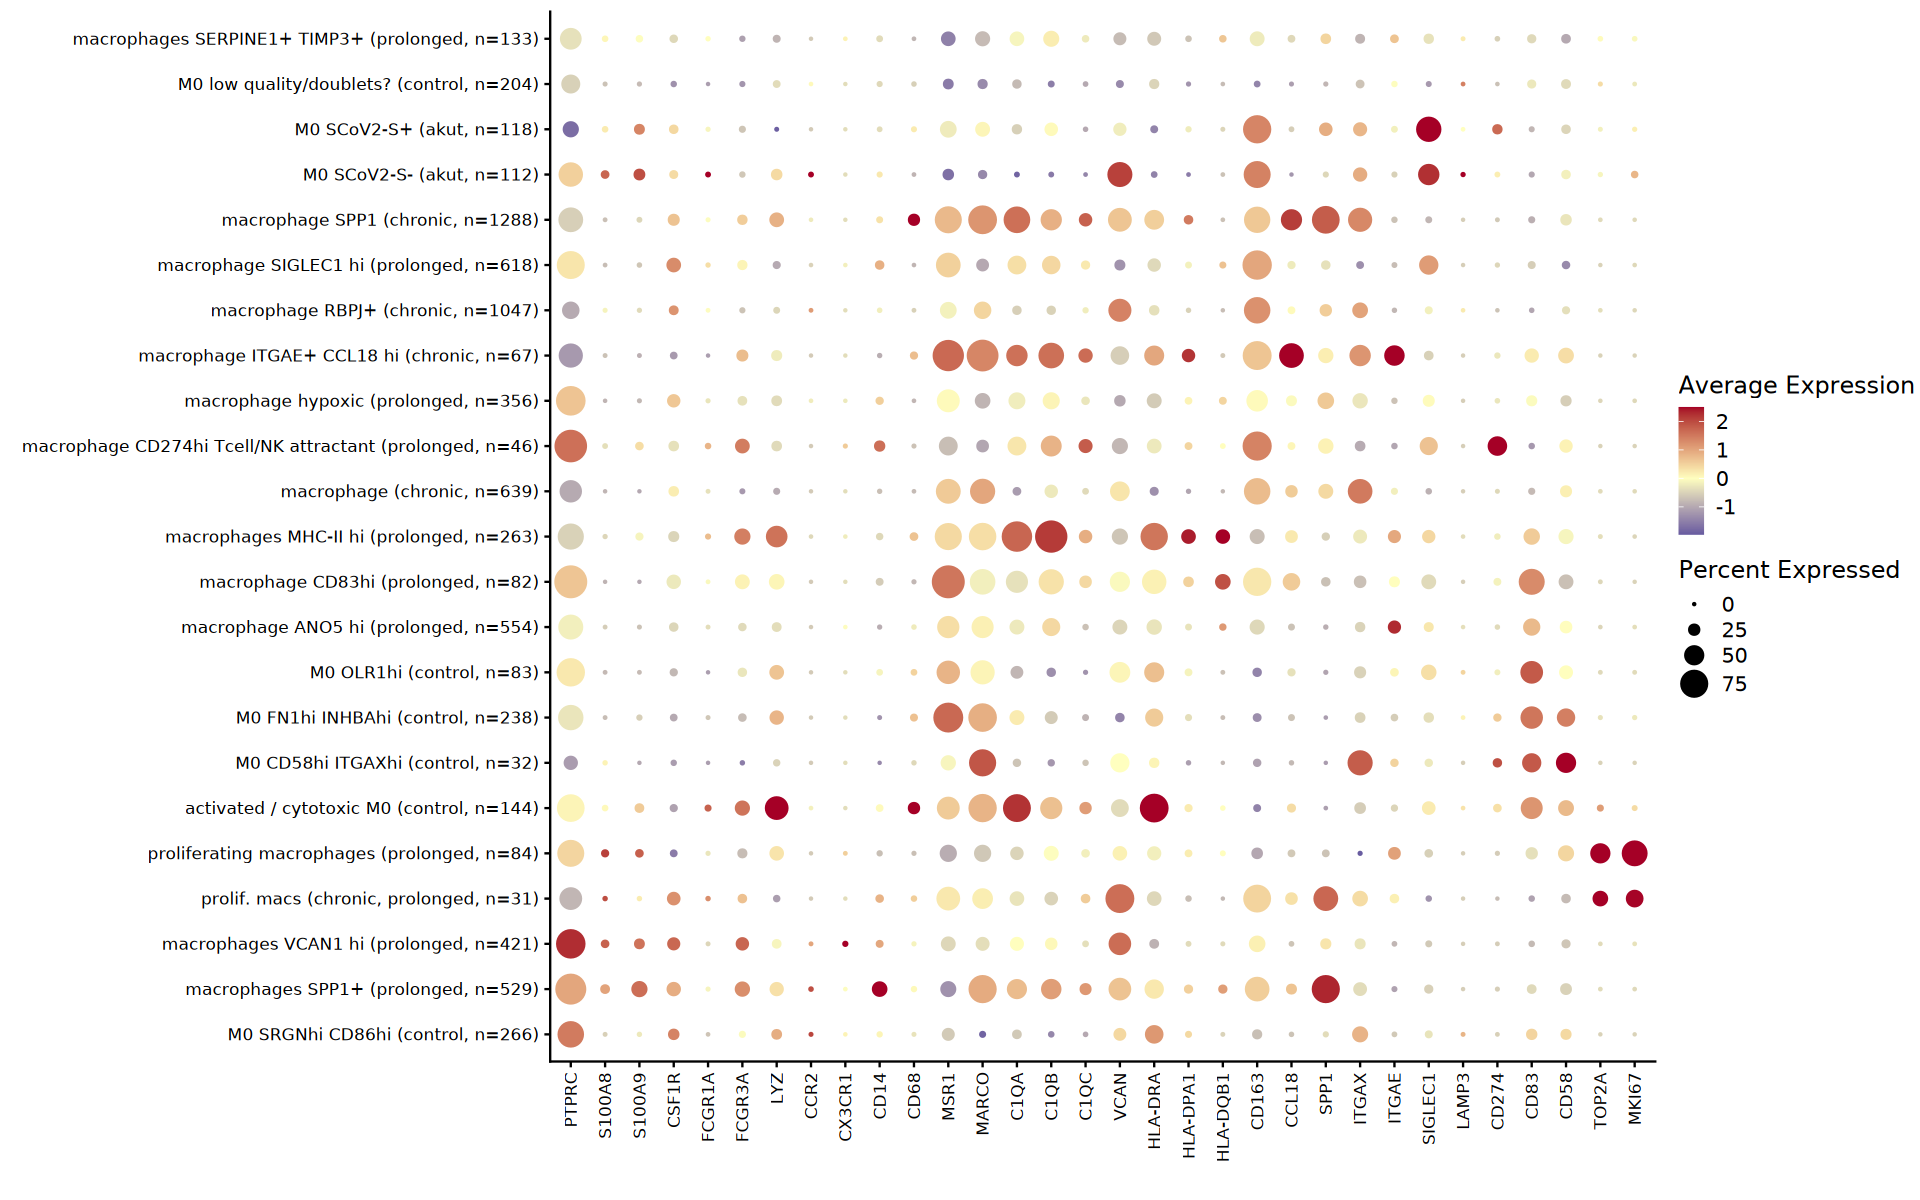

In [32]:
options(repr.plot.width = 16, repr.plot.height = 10)

annotations <- sort(unique(se@meta.data$annotation_lvl4))
cell_type_order <- c(grep("^(M0 SRGNhi CD86hi|macrophages SPP1\\+|macrophages VCAN1 hi|prolif\\. macs|proliferating macrophages)$", annotations, value = TRUE, ignore.case = TRUE, perl = TRUE),
                     grep("^(macrophages MHC-II hi|macrophage CD83hi|macrophage ANO5 hi|M0 OLR1hi|M0 FN1hi INHBAhi|M0 CD58hi ITGAXhi|activated / cytotoxic M0)$", annotations, value = TRUE, ignore.case = TRUE, perl = TRUE),
                     grep("^(macrophage CD274hi Tcell/NK attractant|macrophage hypoxic|macrophage ITGAE\\+ CCL18 hi|macrophage RBPJ\\+|macrophage SIGLEC1 hi|macrophage SPP1|macrophage)$", annotations, value = TRUE, ignore.case = TRUE, perl = TRUE),
                     grep("^M0 SCoV2-S", annotations, value = TRUE, ignore.case = TRUE, perl = TRUE),
                     grep("^(M0 low quality/doublets\\?|macrophages SERPINE1\\+ TIMP3\\+)$", annotations, value = TRUE, ignore.case = TRUE, perl = TRUE))

dotplot("mac|M0", annot_col = "annotation_lvl4", use_order = TRUE,
        c("PTPRC", "S100A8", "S100A9", "CSF1R", "FCGR1A", "FCGR3A", "LYZ", "CCR2", "CX3CR1", "CD14", 
          "CD68", "MSR1", "MARCO", "C1QA", "C1QB", "C1QC", "VCAN", "HLA-DRA", "HLA-DPA1", "HLA-DQB1", 
          "CD163", "CCL18", "SPP1", "ITGAX", "ITGAE", "SIGLEC1", "LAMP3", "CD274", "CD83", "CD58",
         "TOP2A", "MKI67"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


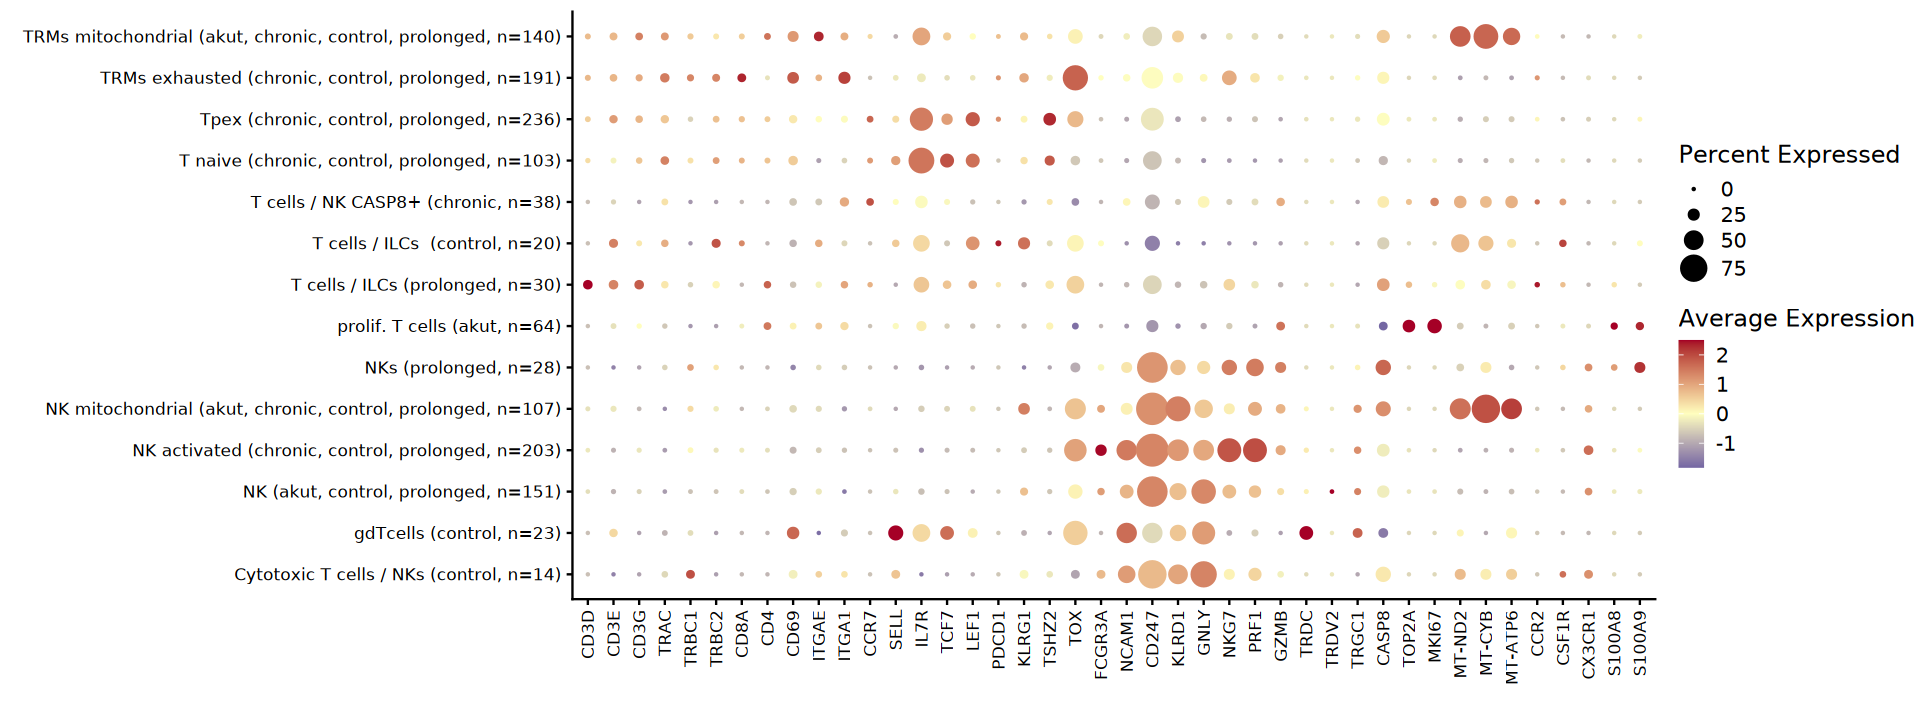

In [33]:
options(repr.plot.width = 16, repr.plot.height = 6) 

dotplot("^(?!.*(macrophage|mast)).*(T[ ]?cells|Cytotoxic T|NK|Tpex|gdTcells|T naive|TRMs)", annot_col = "annotation_lvl4", 
       c("CD3D", "CD3E", "CD3G", "TRAC", "TRBC1", "TRBC2", # Pan-t
         "CD8A", "CD4", "CD69", "ITGAE", "ITGA1", #TRMs
         "CCR7", "SELL", "IL7R", "TCF7", "LEF1", "PDCD1", "KLRG1", "TSHZ2", # T pex/naive
         "TOX",
         "FCGR3A", "NCAM1", "CD247",  "KLRD1","GNLY", "NKG7","PRF1", "GZMB", # NK
         "TRDC", "TRDV2", "TRGC1", # gdT 
         "CASP8", "TOP2A", "MKI67", "MT-ND2", "MT-CYB", "MT-ATP6",
         "CCR2", "CSF1R", "CX3CR1", "S100A8", "S100A9"))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


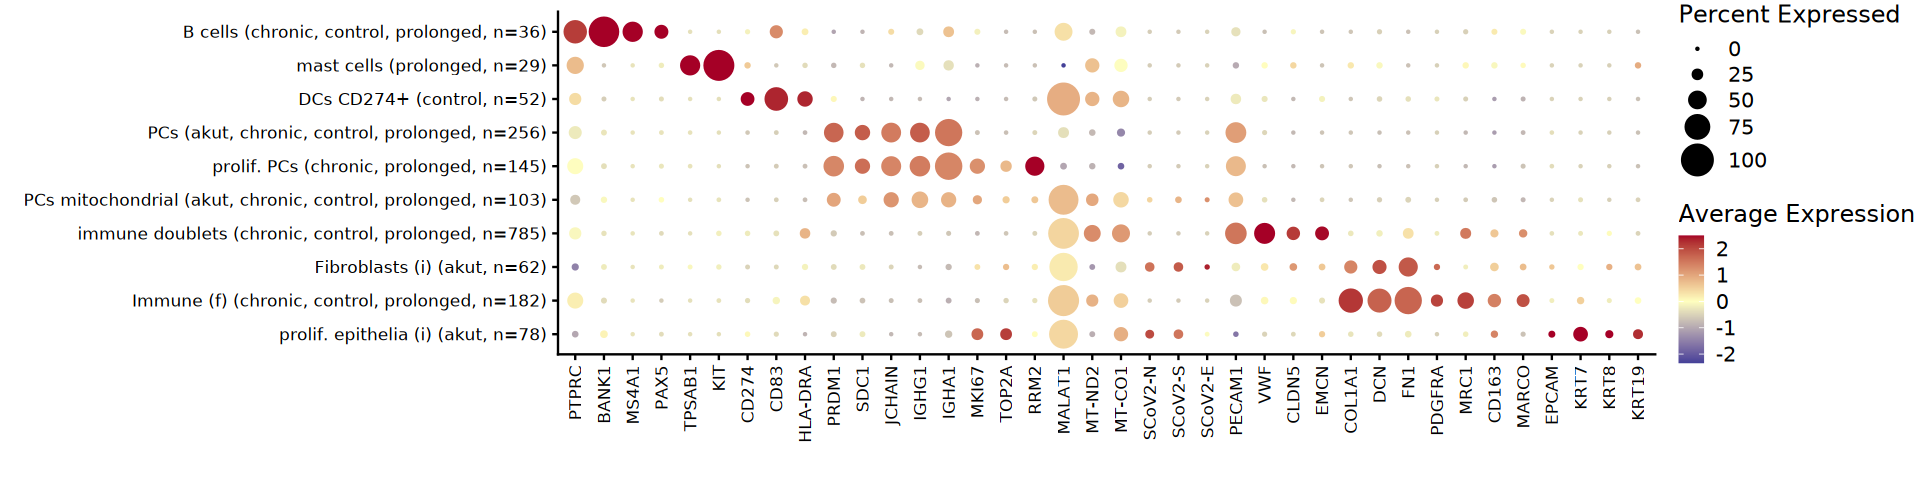

In [34]:
options(repr.plot.width = 16, repr.plot.height = 4) 

cell_type_order <- c("prolif. epithelia (i)", "Immune (f)", "Fibroblasts (i)", "immune doublets",
                     "PCs mitochondrial", "prolif. PCs", "PCs", "DCs CD274+", "mast cells", "B cells")
dotplot("PCs|DCs|B cells|mast|immune| \\(i\\)", annot_col = "annotation_lvl4", use_order = TRUE,
       c("PTPRC","BANK1","MS4A1","PAX5", # B cells
         "TPSAB1","KIT", # mast
         "CD274","CD83","HLA-DRA",# DC
         "PRDM1","SDC1","JCHAIN","IGHG1","IGHA1", # PCs
         "MKI67","TOP2A","RRM2", # Proliferation
         "MALAT1","MT-ND2","MT-CO1", 
         "SCoV2-N","SCoV2-S","SCoV2-E",
         "PECAM1", "VWF", "CLDN5", "EMCN", # ECs
         "COL1A1", "DCN", "FN1", "PDGFRA", # Fibro
         "MRC1","CD163","MARCO", # m0
         "EPCAM", "KRT7", "KRT8", "KRT19")) # Epithelial

In [35]:
se@meta.data <- se@meta.data %>% 
    mutate(
        annotation = case_when(
            grepl("^SMC", annotation_lvl4, ignore.case = TRUE) ~ "SMC",
            grepl("\\(SMC\\)", annotation_lvl4, ignore.case = TRUE) ~ "LowQ (SMC)",
            grepl("^Pericytes", annotation_lvl4, ignore.case = TRUE) ~ "Pericytes",
            grepl("Activated vascular SMC / Pericytes", annotation_lvl4, ignore.case = TRUE) ~ "Pericytes",
            
            grepl("^(?!.*(stressed)).*?(gCaps)", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "gCaps",
            grepl("stressed", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "LowQ (gCaps)",
            grepl("aerocytes", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Aerocytes", 
             grepl("ECs \\(SARS-CoV-2\\+\\)", annotation_lvl4, ignore.case = TRUE) ~ "LowQ (ECs)",
            grepl("Doublets \\(epithelia-endothelia\\)", annotation_lvl4, ignore.case = TRUE) ~ "Doublets (epithelia-endothelia)",
            grepl("^(?!.*(SARS)).*?(^ECs)", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "LowQ (ECs)",
            grepl("Lymphatic ECs", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Lymphatic ECs",
            grepl("Venous ECs", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Venous ECs", 
            grepl("Arterial ECs", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Arterial ECs", 
            
            grepl("LowQ \\(Epithelia\\)", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "LowQ (Epithelia)",
            grepl("prolif. epithelia", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "LowQ (Epithelia)",
            grepl("AT1", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "AT1",
            grepl("AT2", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "AT2",
            grepl("Club", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Club cells",
            grepl("Basal", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Basal cells",
            grepl("Ciliated", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Ciliated cells",

            grepl("AlvF/AdvF", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Doublets (AlvF-AdvF)",  
            grepl("Proliferating Fibroblasts", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "AdvF", 
            grepl("^(?!.*(\\(i\\))).*?(^Fibroblasts)", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "AdvF",  
            grepl("^(?!.*(inflammatory)).*?(^AdvF)", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "AdvF",  
            grepl("AlvF", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "AlvF", 
            grepl("AlvF CEMIP", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "AlvF",
            grepl("AdvF inflammatory", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "LowQ (AdvF)",  
            grepl("fibro.*?\\(i\\)|immune", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "Doublets (immune-endo-fibro)",

            grepl("^(M0 SRGNhi CD86hi|macrophages SPP1\\+|macrophages VCAN1 hi|prolif\\. macs|proliferating macrophages)$", annotation_lvl4, ignore.case = TRUE) ~ "Monocytes",
            grepl("^(macrophages MHC-II hi|macrophage CD83hi|macrophage ANO5 hi|M0 OLR1hi|M0 FN1hi INHBAhi|M0 CD58hi ITGAXhi|activated / cytotoxic M0)$", annotation_lvl4, ignore.case = TRUE) ~ "Inflammatory Macrophages",
            grepl("^(macrophage CD274hi Tcell/NK attractant|macrophage hypoxic|macrophage ITGAE\\+ CCL18 hi|macrophage RBPJ\\+|macrophage SIGLEC1 hi|macrophage SPP1|macrophage)$", annotation_lvl4, ignore.case = TRUE) ~ "Anti-inflammatory Macrophages",
            grepl("^M0 SCoV2-S", annotation_lvl4, ignore.case = TRUE) ~ "Phagocytic macrophages",
            grepl("^(M0 low quality/doublets\\?|macrophages SERPINE1\\+ TIMP3\\+)$", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "LowQ (macrophages)",

            grepl("TRMs", annotation_lvl4, ignore.case = TRUE) ~ "T cells", #TRMs / tcells
            grepl("Tpex|T naive", annotation_lvl4, ignore.case = TRUE) ~ "T cells", #Tpex / tcells
            grepl("T cells / ILCs", annotation_lvl4, ignore.case = TRUE) ~ "T cells", #Tex / tcells
            grepl("gdTcells", annotation_lvl4, ignore.case = TRUE) ~ "T cells", #gdT / tcells
            grepl("prolif. T cells", annotation_lvl4, ignore.case = TRUE) ~ "LowQ (T cells)",
            grepl("T cells / NK CASP8+", annotation_lvl4, ignore.case = TRUE) ~ "LowQ (T cells)",
            grepl("^(?!.*(CASP|macrophage)).*?(NK)", annotation_lvl4, ignore.case = TRUE, perl = TRUE) ~ "NK cells", # nk
            
            grepl("B cells", annotation_lvl4, ignore.case = TRUE) ~ "B cells",
            grepl("mast", annotation_lvl4, ignore.case = TRUE) ~ "Mast cells",             
            grepl("DCs", annotation_lvl4, ignore.case = TRUE) ~ "LowQ (DCs)", 
            grepl("PCs", annotation_lvl4, ignore.case = TRUE) ~ "PCs", 
            
            TRUE ~ "WARNING"
        )
    )

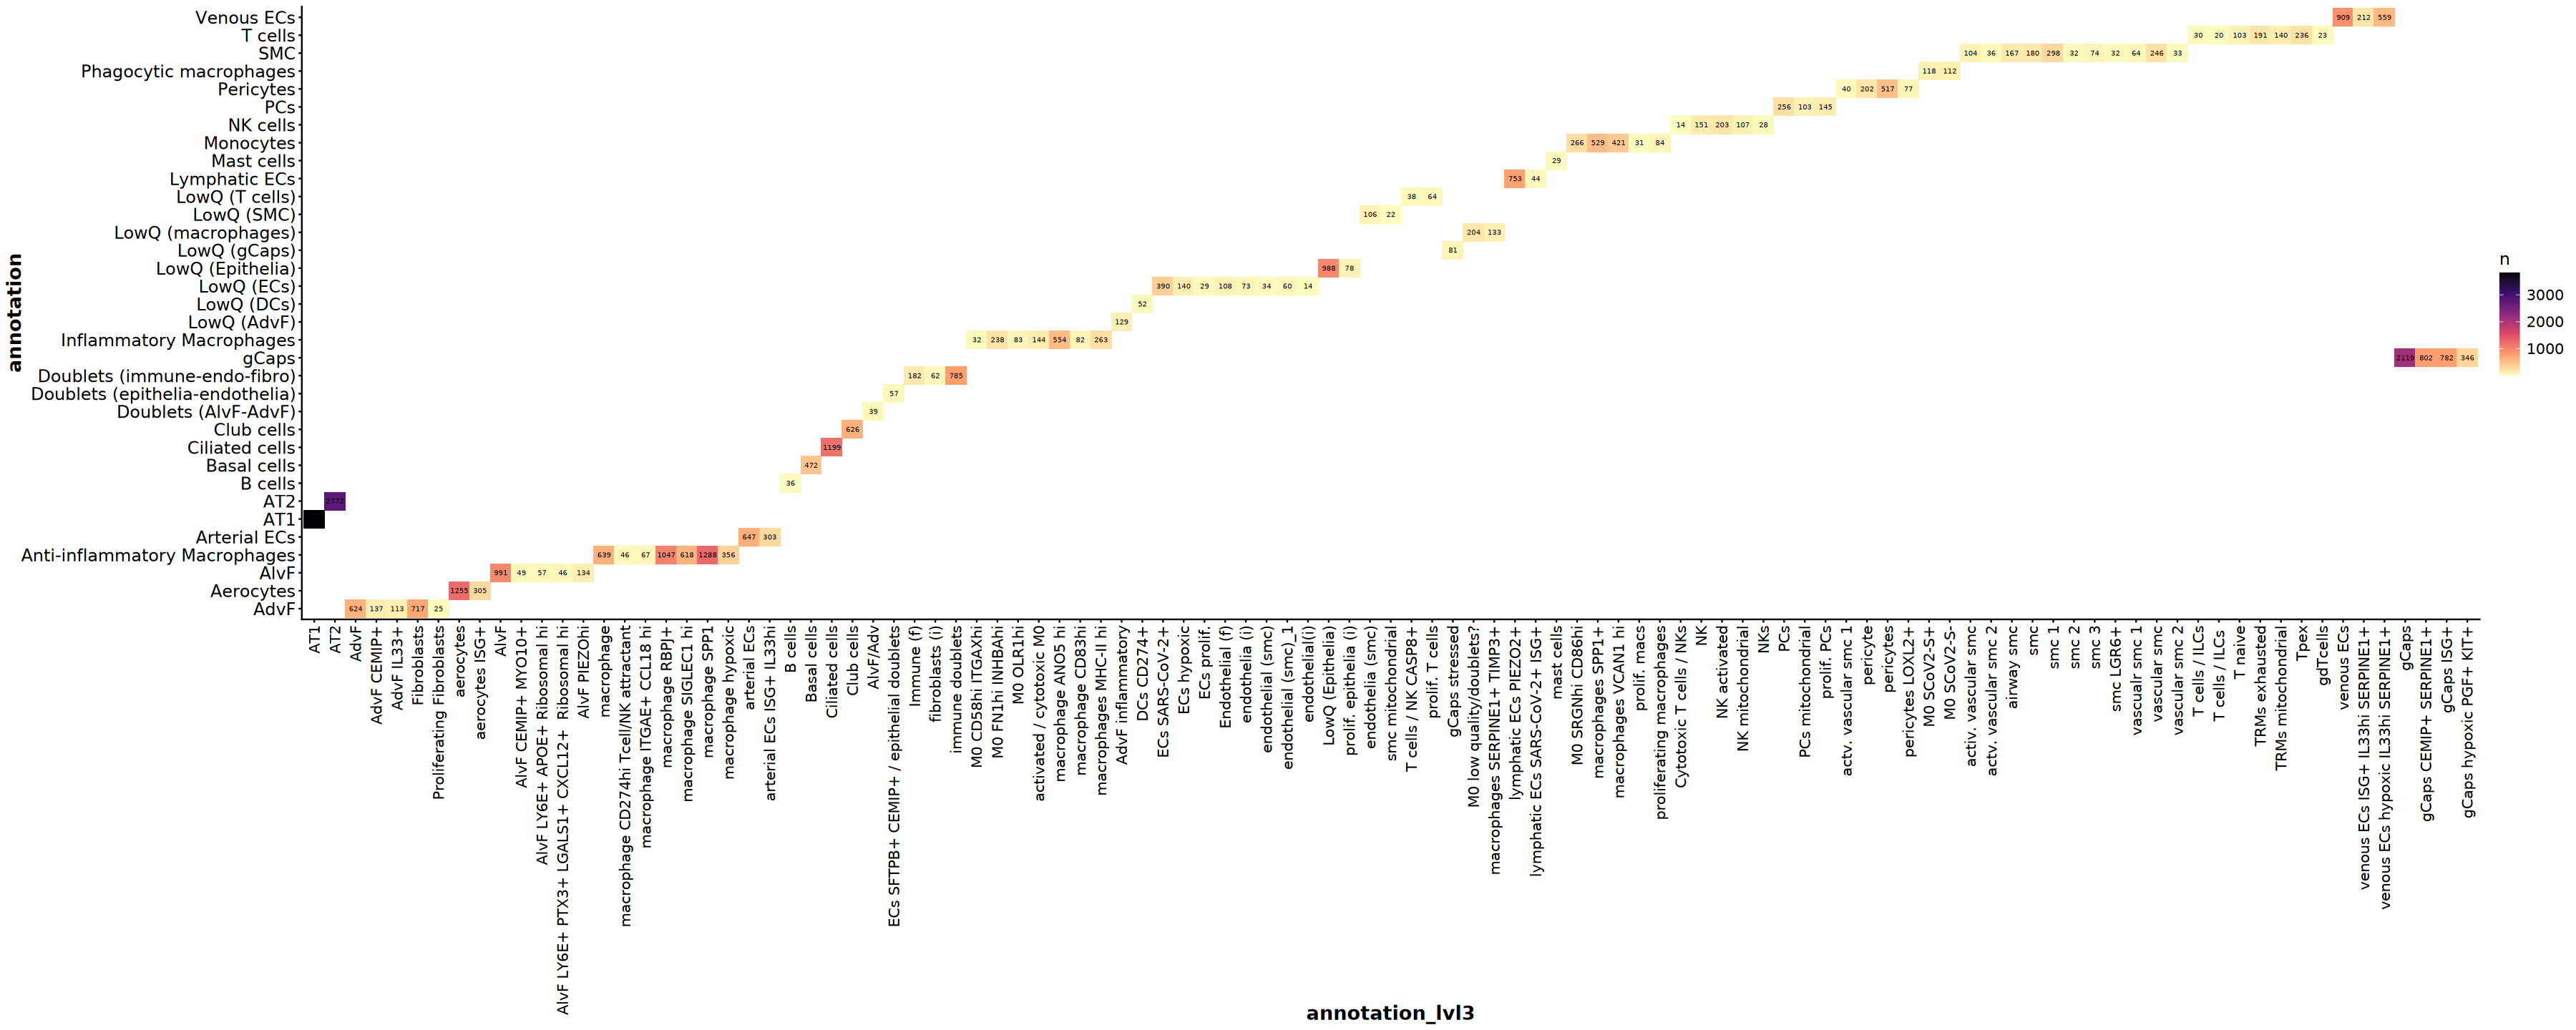

In [36]:
options(repr.plot.width = 30, repr.plot.height = 12) 

lvl3_order <- se@meta.data %>%
    select(annotation, annotation_lvl3) %>%
    distinct() %>%
    arrange(annotation, annotation_lvl3) %>%
    pull(annotation_lvl3)

se@meta.data %>%
    dplyr::count(annotation, annotation_lvl3) %>%
    mutate(annotation_lvl3 = factor(annotation_lvl3, levels = lvl3_order)) %>%
    ggplot(aes(x = annotation_lvl3, y = annotation, fill = n, label = n)) +
    geom_tile() +
    geom_text(color = "black", size = 2) +
    scale_fill_viridis_c(option = "magma", direction = -1) + 
    theme_classic() +
    theme(
        axis.text.x = element_text(hjust = 1, vjust = 0.5, angle = 90, size = 12),
        axis.text.y = element_text(size = 14),
        axis.title = element_text(size = 16, face = "bold"),
        legend.title = element_text(size = 14),
        legend.text = element_text(size = 12)
    )

In [37]:
cat("Number of cells before filtering:", ncol(se), "\n")

n_to_remove <- sum(grepl("LowQ|Doublets", se@meta.data$annotation))
cat("Number of cells with LowQ or Doublets:", n_to_remove, "\n")

se_filtered <- subset(se, subset = !grepl("LowQ|Doublets", annotation))
cat("Number of cells after filtering:", ncol(se_filtered), "\n")

Number of cells before filtering: 35625 
Number of cells with LowQ or Doublets: 3868 
Number of cells after filtering: 31757 


## Reprocessing

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations



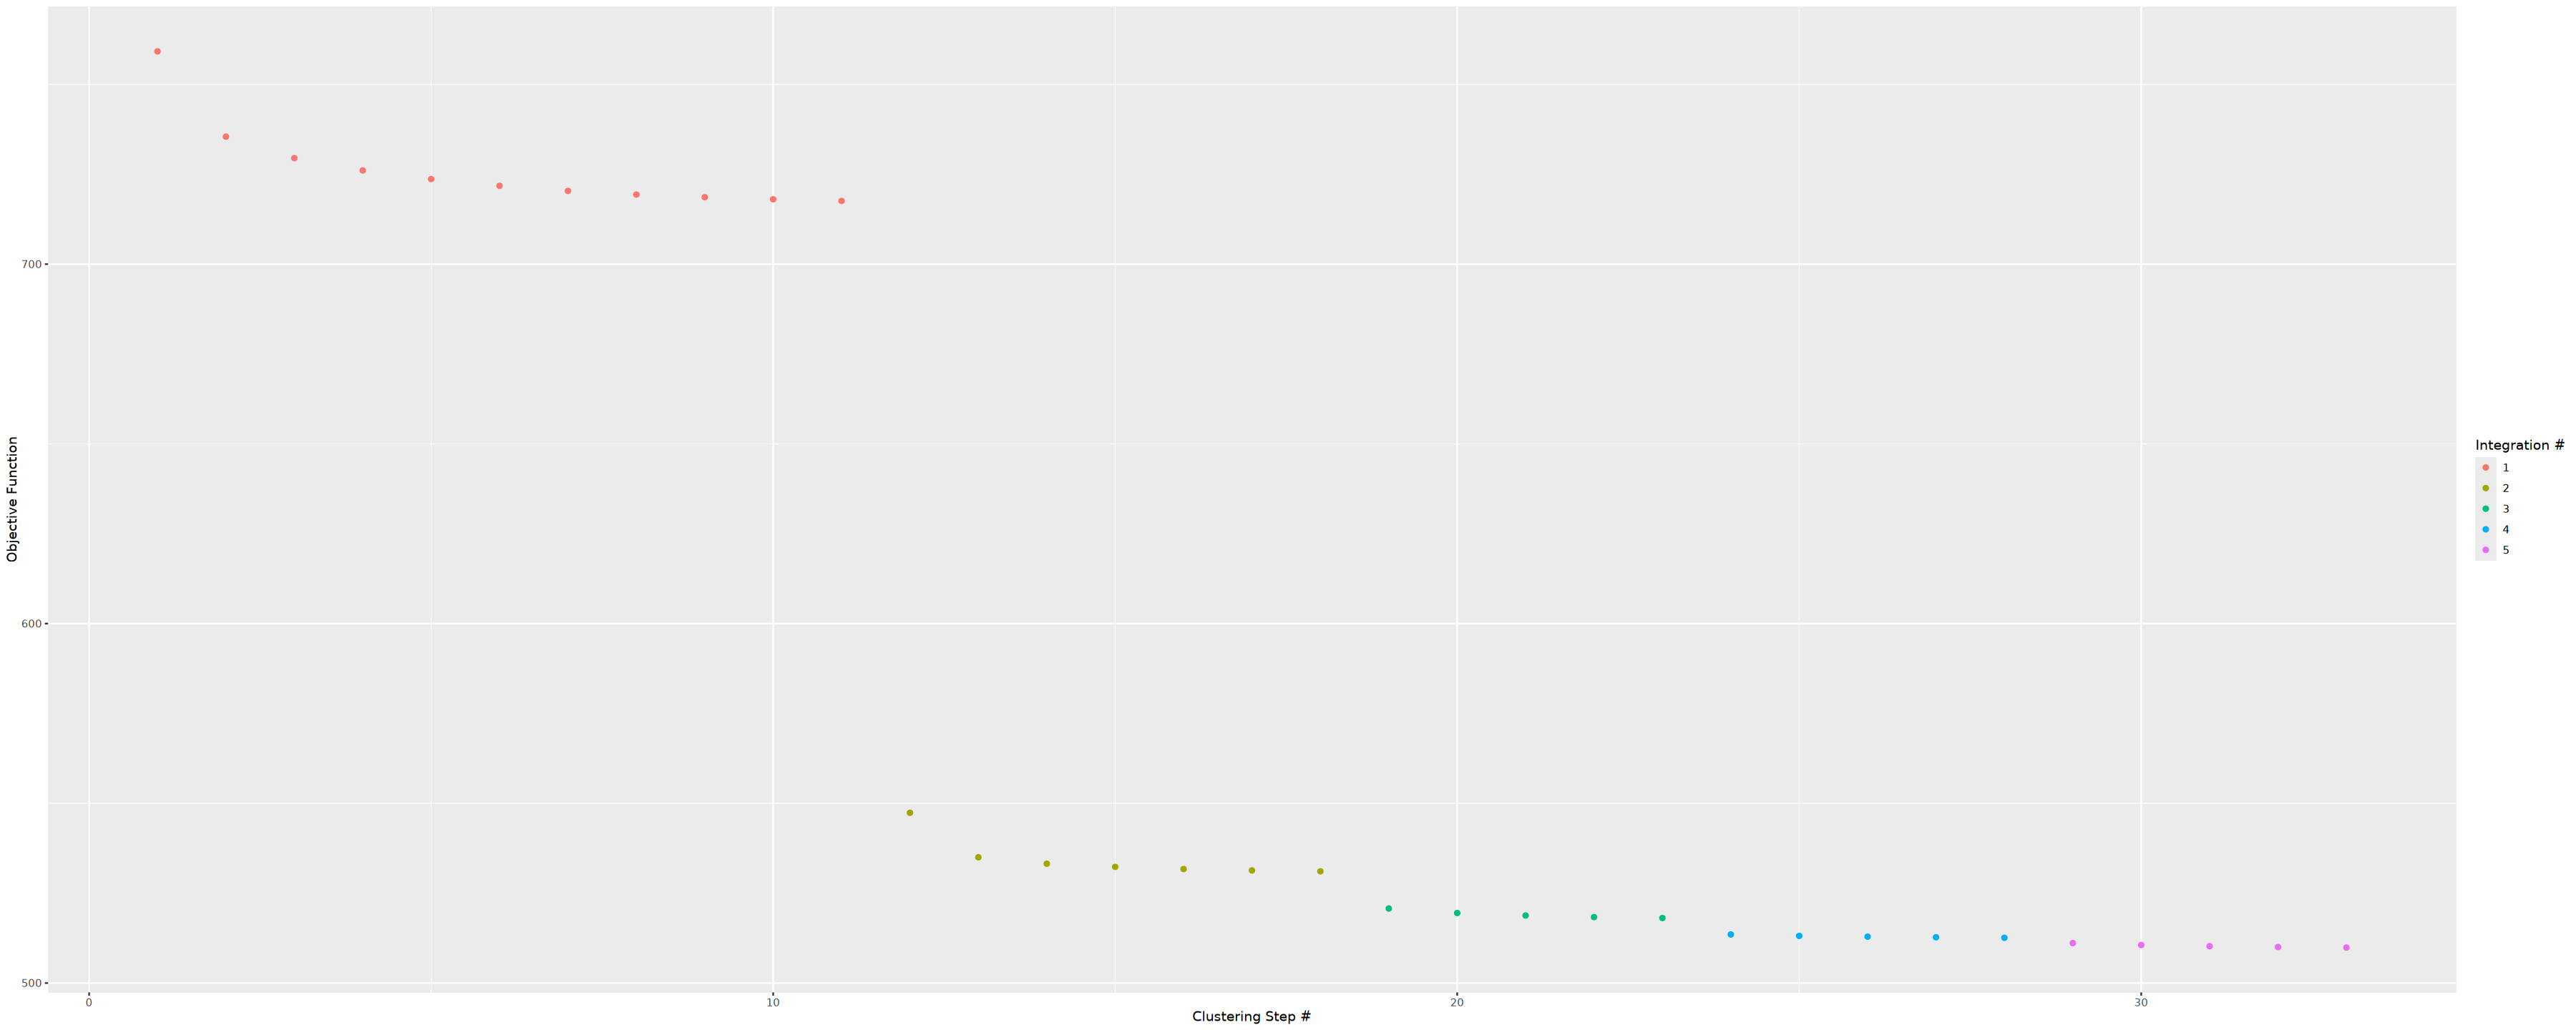

In [38]:
se_filtered <- Seurat::NormalizeData(se_filtered, verbose = FALSE) %>%
    Seurat::FindVariableFeatures(selection.method = "vst", nfeatures = 3000) %>% 
    Seurat::ScaleData(verbose = FALSE) %>% 
    Seurat::RunPCA(pc.genes = .@var.genes, npcs = 50, verbose = FALSE)

se_filtered <- se_filtered %>% harmony::RunHarmony(object = ., group.by.vars = "donor", reduction.use = "pca", plot_convergence = TRUE, seed.use = 42)
se_filtered <- se_filtered %>% Seurat::RunUMAP(reduction = "harmony", dims = 1:30, n.components = 3, verbose = FALSE, seed.use = 42)

Saving 6.67 x 6.67 in image


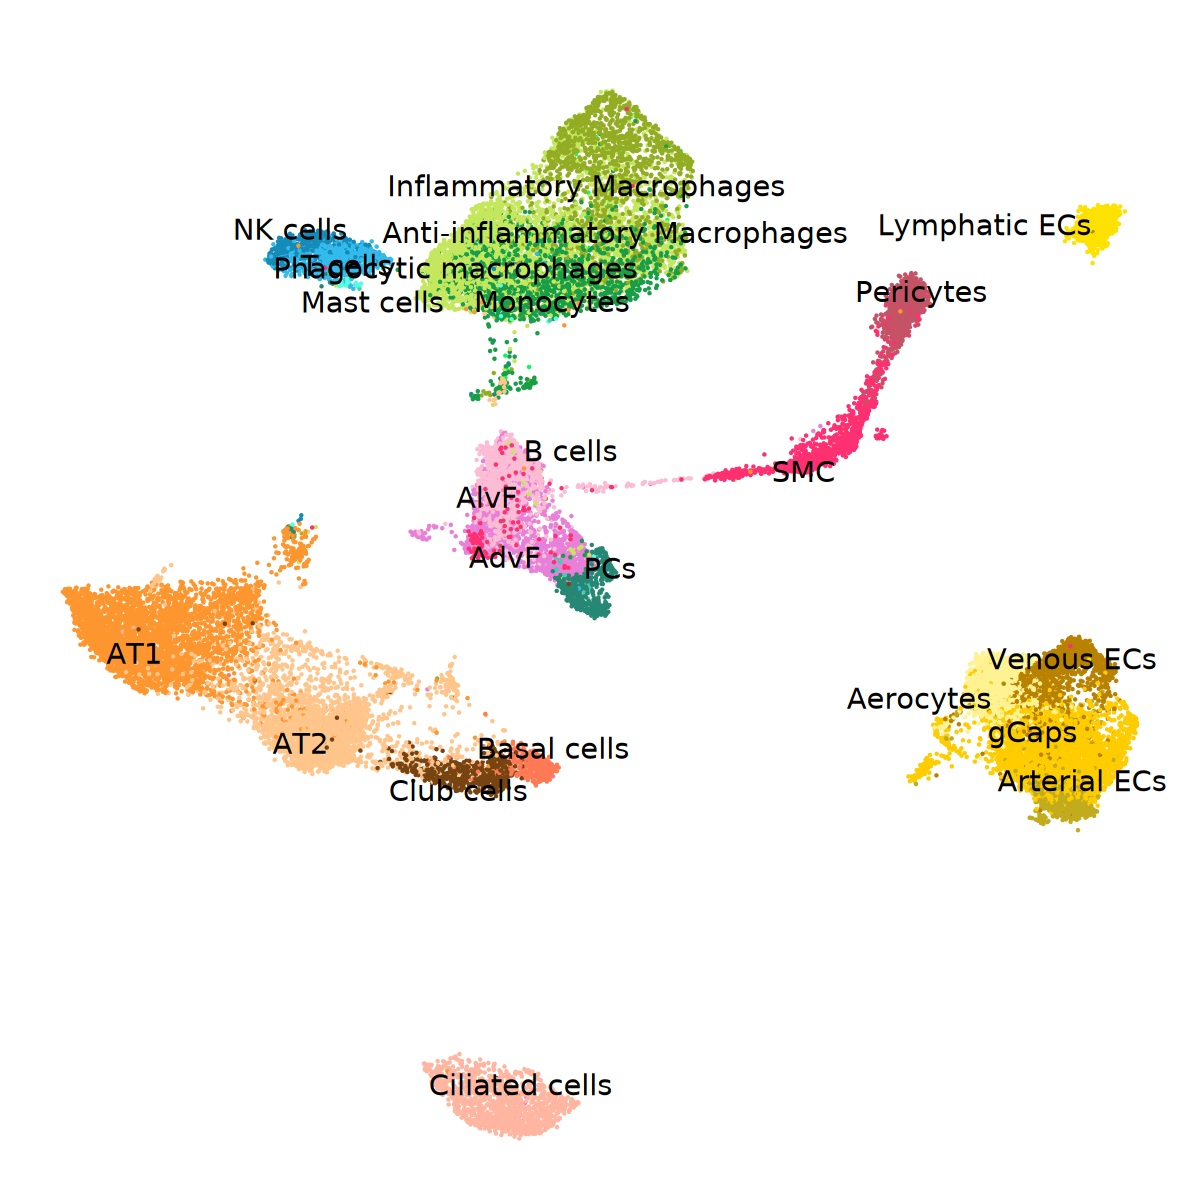

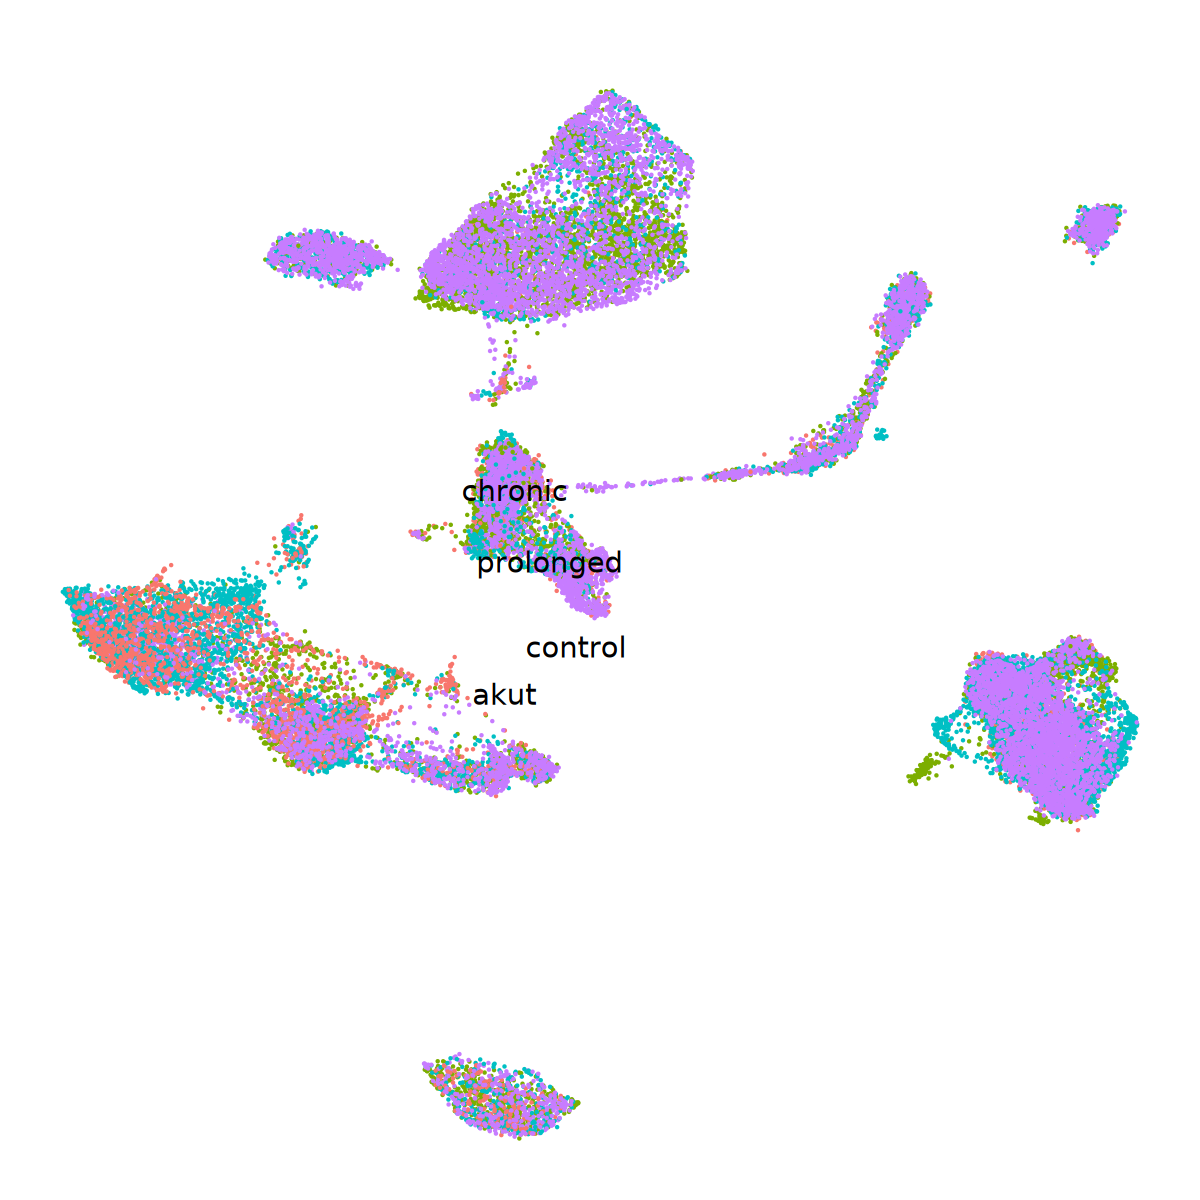

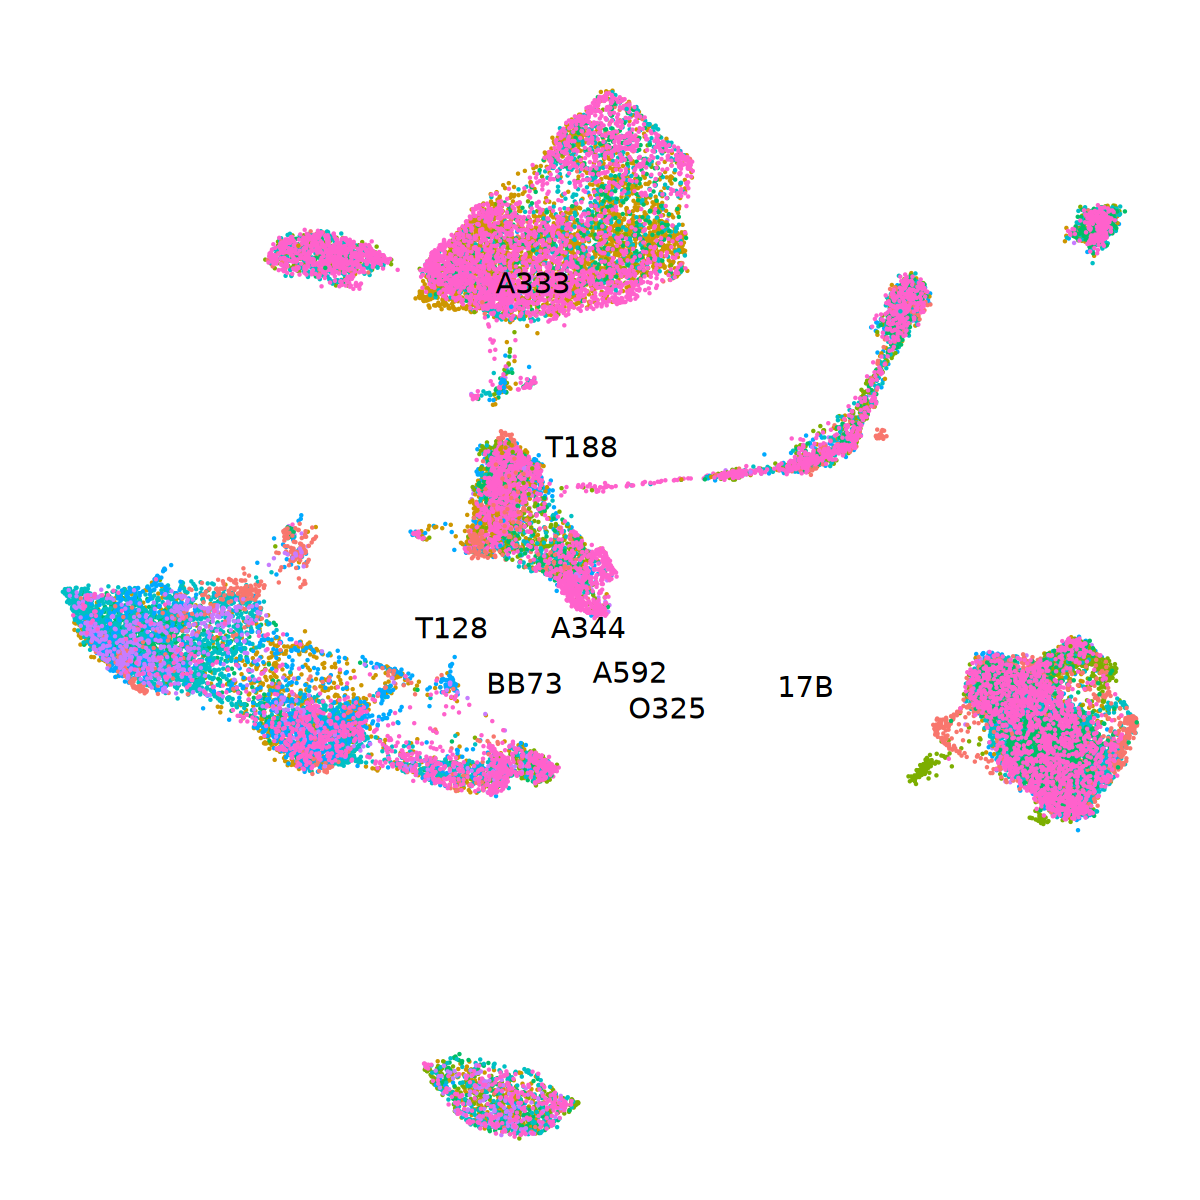

In [39]:
options(repr.plot.width = 10, repr.plot.height = 10, ggrepel.max.overlaps = Inf) 

palette <- c("SMC" = "#FF3071", "Pericytes" = "#C45365",
             "AdvF" = "#E87FD8", "AlvF" = "#FCBCD3", 
             "Aerocytes" = "#FFF292", "gCaps" = "#FFCC00", "Arterial ECs" = "#C2AC1D", "Venous ECs" = "#B88100", "Lymphatic ECs" = "#FFE100",
             "AT1" = "#FE962F", "AT2" = "#FFC58B", "Basal cells" = "#FF7A54", "Ciliated cells" = "#FFB59F", "Club cells" = "#774411",
             "Monocytes" = "#179E46", "Inflammatory Macrophages" = "#92AD24", "Anti-inflammatory Macrophages" = "#C4E75D", "Phagocytic macrophages" = "#00FF59",
             "Mast cells" = "#53FFDD", "B cells" = "#48CBB1", "PCs" = "#268874", "DCs" = "#B5E4F4", "T cells" = "#33BBEE", "NK cells" = "#148BB8")

p <- Seurat::DimPlot(object = se_filtered, group.by = "annotation", 
                repel = TRUE, raster = FALSE, 
                label = TRUE, label.size = 6,
                cols = palette) + 
                labs(title = "") + 
                theme_void() + 
                NoLegend()
ggsave("~/SP-COVID/snRNAseq/0-annotation/out/plots/umap.svg", plot = p, device = svglite)
print(p)

Seurat::DimPlot(object = se_filtered, group.by = "condition", 
                repel = TRUE, raster = FALSE, 
                label = TRUE, label.size = 6) + 
                labs(title = "") + 
                theme_void() + 
                NoLegend()

Seurat::DimPlot(object = se_filtered, group.by = "donor", 
                repel = TRUE, raster = FALSE, 
                label = TRUE, label.size = 6) + 
                labs(title = "") + 
                theme_void() + 
                NoLegend()

Warning message:
“The following requested variables were not found: SCGB3A1,”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


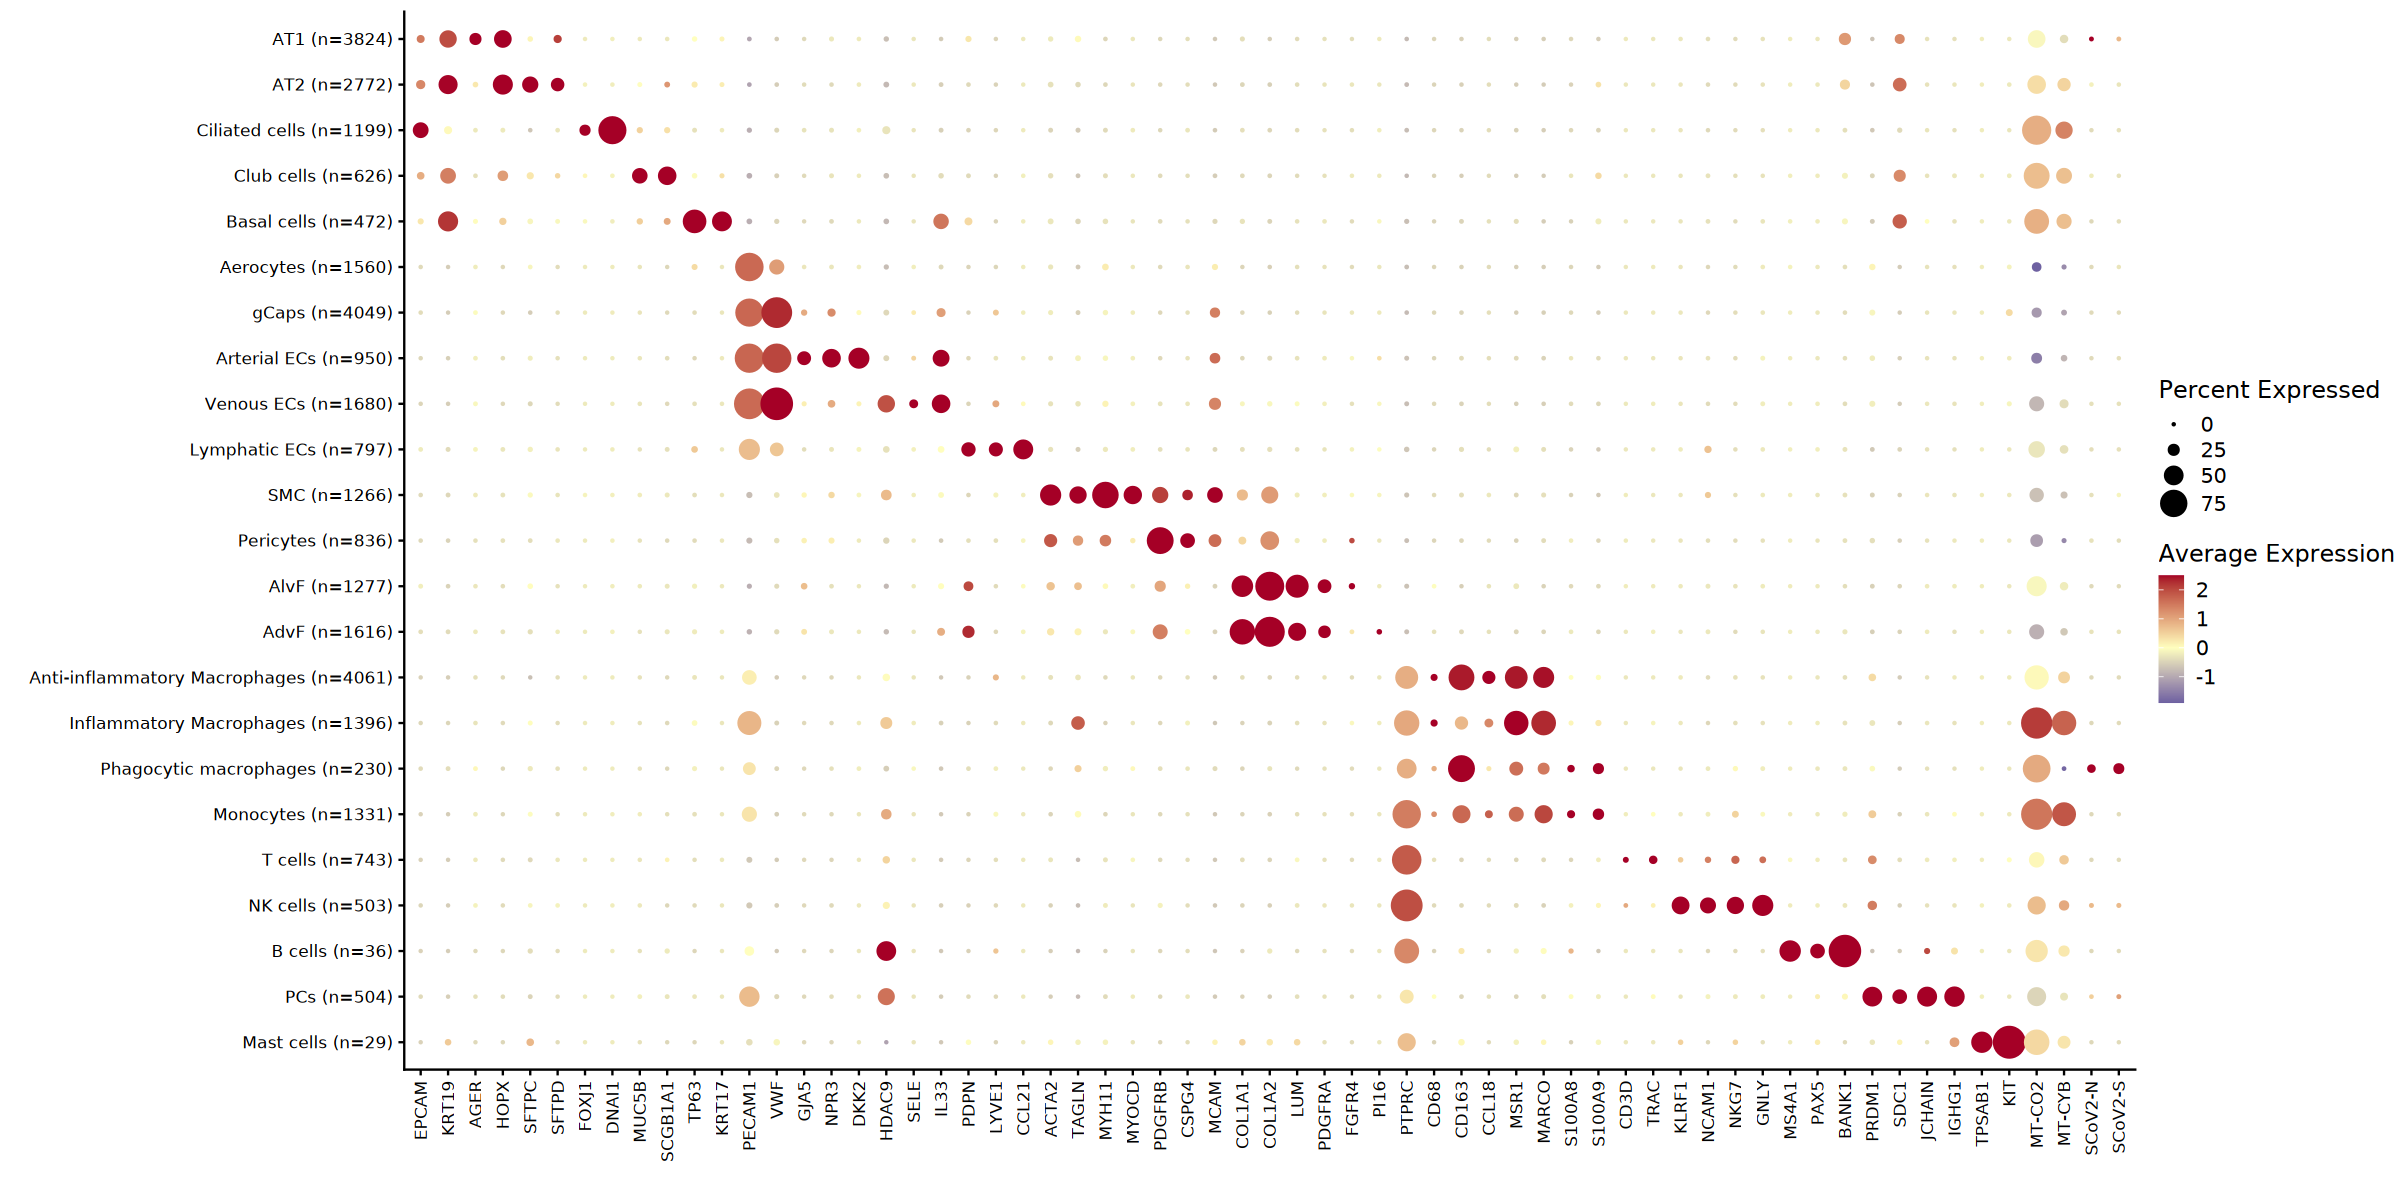

In [40]:
options(repr.plot.width = 20, repr.plot.height = 10) 

cell_type_order <- c("Mast cells", "PCs", "B cells", "NK cells",  "T cells", "DCs", 
                     "Monocytes", "Phagocytic macrophages", "Inflammatory Macrophages", "Anti-inflammatory Macrophages",
                     "AdvF", "AlvF", "Pericytes", "SMC",
                     "Lymphatic ECs", "Venous ECs", "Arterial ECs", "gCaps", "Aerocytes", 
                     "Basal cells", "Club cells", "Ciliated cells",
                     "AT2", "AT1")

p <- dotplot("", annot_col = "annotation", use_order = TRUE, seurat_obj = se_filtered, show_condition_map = FALSE, 
       c("EPCAM", "KRT19", # Epithelial cells
         "AGER", "HOPX", # at1
         "SFTPC", "SFTPD", # at2
         "FOXJ1", "DNAI1", # ciliated
         "MUC5B", "SCGB1A1", "SCGB3A1,",  # club
         "TP63", "KRT17", # Basal
         "PECAM1", "VWF", # Endothelial cells / Aerocytes
         "GJA5", "NPR3", "DKK2", # Arterial 
         "HDAC9",  "SELE", "IL33", # Venous
         "PDPN", "LYVE1", "CCL21", # Lymphatic
         "ACTA2", "TAGLN", "MYH11", "MYOCD", # Smooth muscle cells
         "PDGFRB", "CSPG4", "MCAM", # Pericytes
         "COL1A1", "COL1A2", "LUM", "PDGFRA", "FGFR4", "PI16", # fibro
         "PTPRC", # Pan-immune
         "CD68", # macs
         "CD163", "CCL18", # anti infmacs
         "MSR1", "MARCO", # inf macs
         "S100A8", "S100A9", # Monocytes
         # "CD83", "HLA-DRA", # DCs
         "CD3D", "TRAC", # Pan-t
         "KLRF1", "NCAM1", "NKG7", "GNLY", # NK cells
         "MS4A1", "PAX5", "BANK1", # B cells
         "PRDM1", "SDC1", "JCHAIN", "IGHG1", # Plasma cells
         "TPSAB1", "KIT", # Mast cells
          "MT-CO2", "MT-CYB", # Mitochondrial
          "SCoV2-N", "SCoV2-S")) # SARS-CoV-2 
ggsave("~/SP-COVID/snRNAseq/0-annotation/out/plots/dotplot_canonical.svg", plot = p, device = svglite, width = 20, height = 10)
print(p)

Calculating cluster Arterial ECs

Calculating cluster Venous ECs

Calculating cluster gCaps

Calculating cluster Lymphatic ECs

Calculating cluster Aerocytes

Calculating cluster AdvF

Calculating cluster AlvF

Calculating cluster NK cells

Calculating cluster Phagocytic macrophages

Calculating cluster PCs

Calculating cluster T cells

Calculating cluster Anti-inflammatory Macrophages

Calculating cluster Monocytes

Calculating cluster B cells

Calculating cluster Inflammatory Macrophages

Calculating cluster Mast cells

Calculating cluster SMC

Calculating cluster Pericytes

Calculating cluster AT2

Calculating cluster AT1

Calculating cluster Ciliated cells

Calculating cluster Basal cells

Calculating cluster Club cells

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


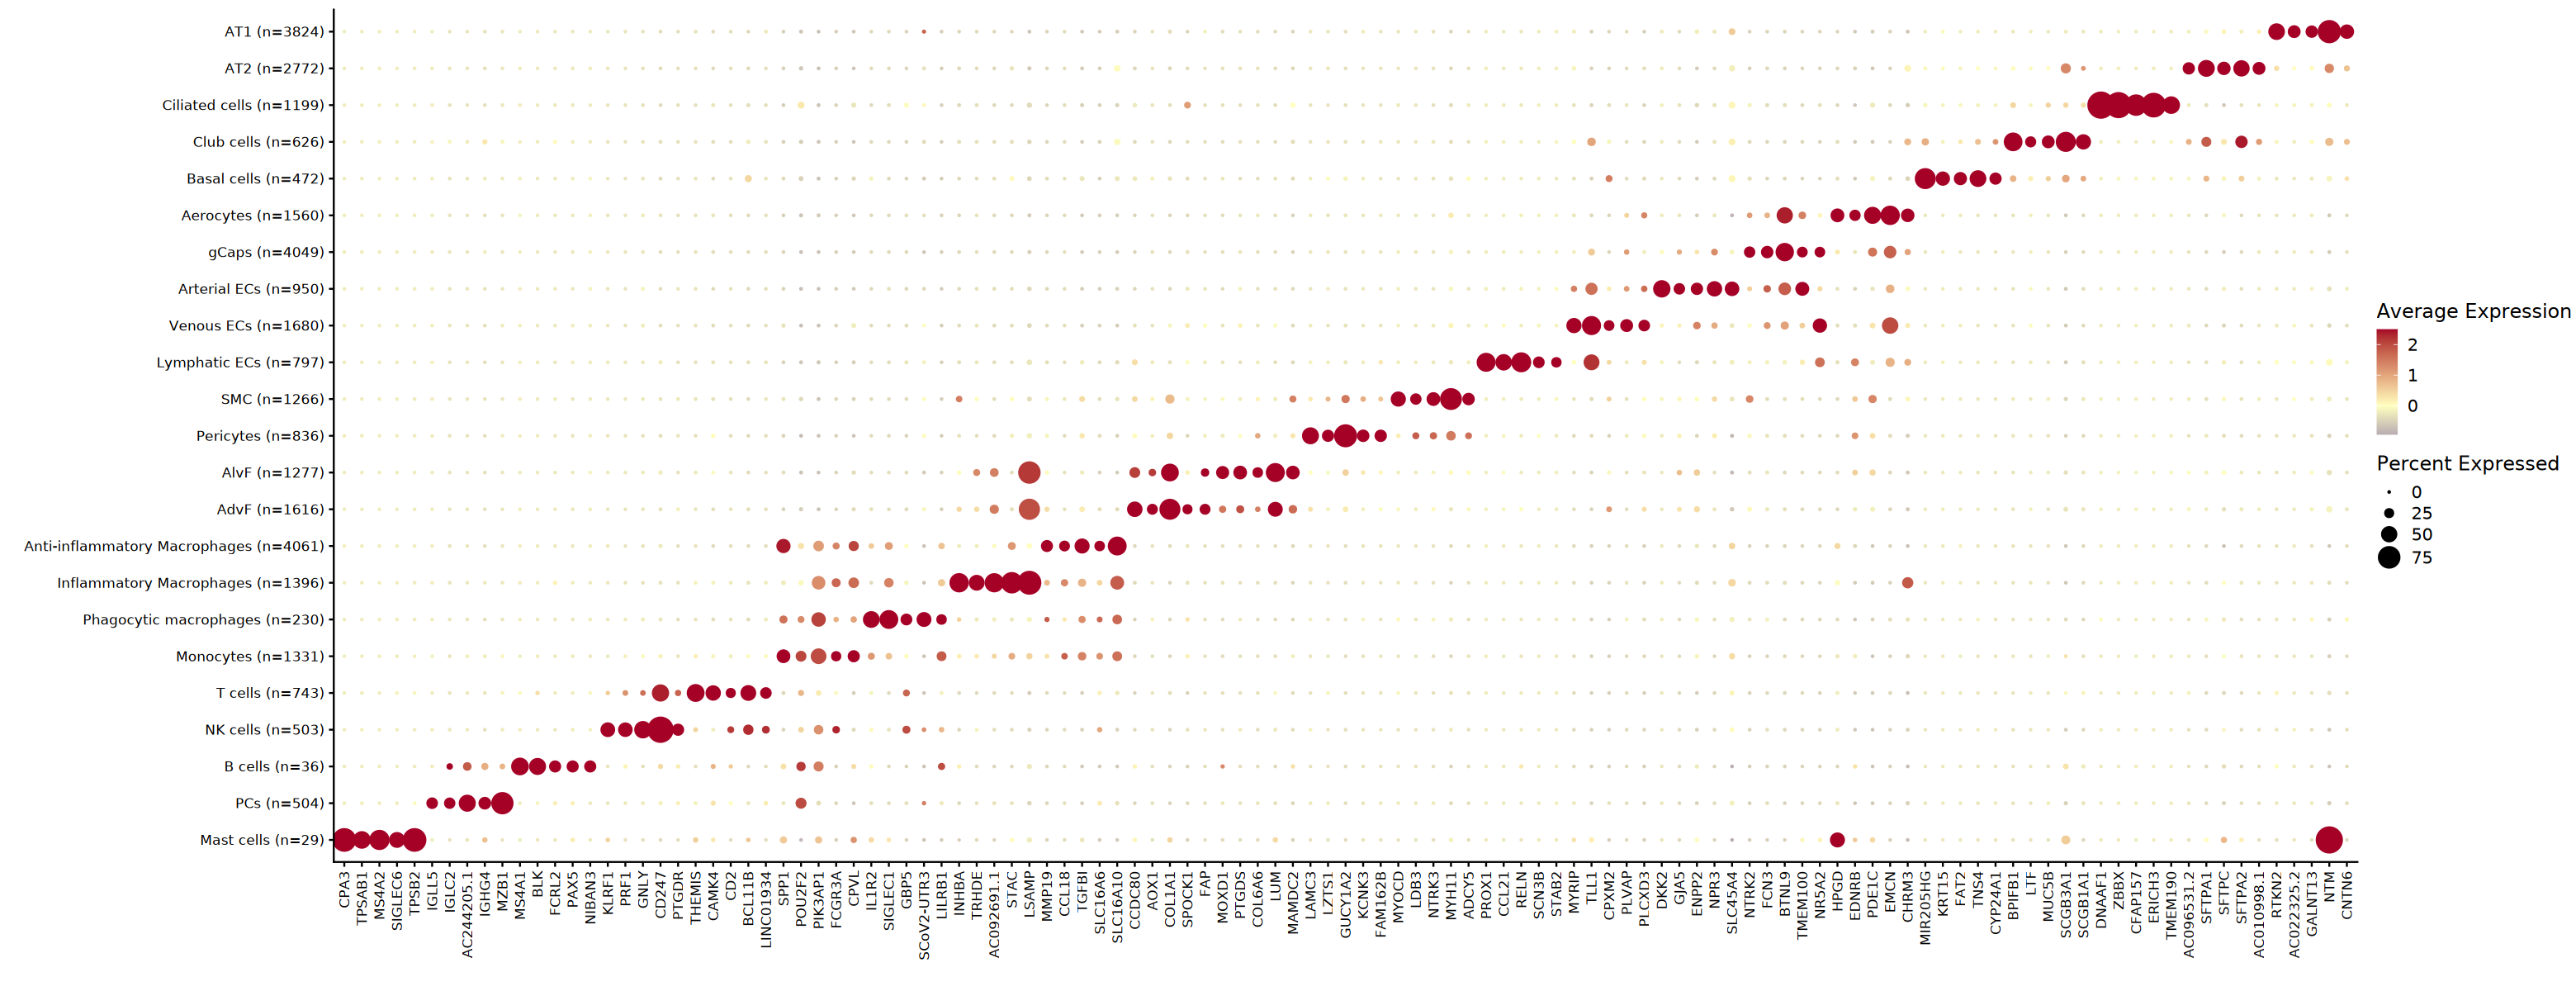

In [41]:
options(repr.plot.width = 26, repr.plot.height = 10) 

Idents(se_filtered) <- "annotation"
markers <- FindAllMarkers(se_filtered, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)

top_markers <- markers %>%
    group_by(cluster) %>%
    slice_max(avg_log2FC, n = 5) %>%
    ungroup()

top_markers_ordered <- top_markers %>%
    mutate(cluster = factor(cluster, levels = cell_type_order)) %>%
    arrange(cluster) %>%
    mutate(gene = factor(gene, levels = unique(gene)))

p <- dotplot("", annot_col = "annotation", use_order = TRUE, show_condition_map = FALSE, seurat_obj = se_filtered, unique(top_markers_ordered$gene))
ggsave("~/SP-COVID/snRNAseq/0-annotation/out/plots/dotplot_markers.svg", plot = p, device = svglite, width = 26, height = 10)
print(p)

Saving 6.67 x 6.67 in image


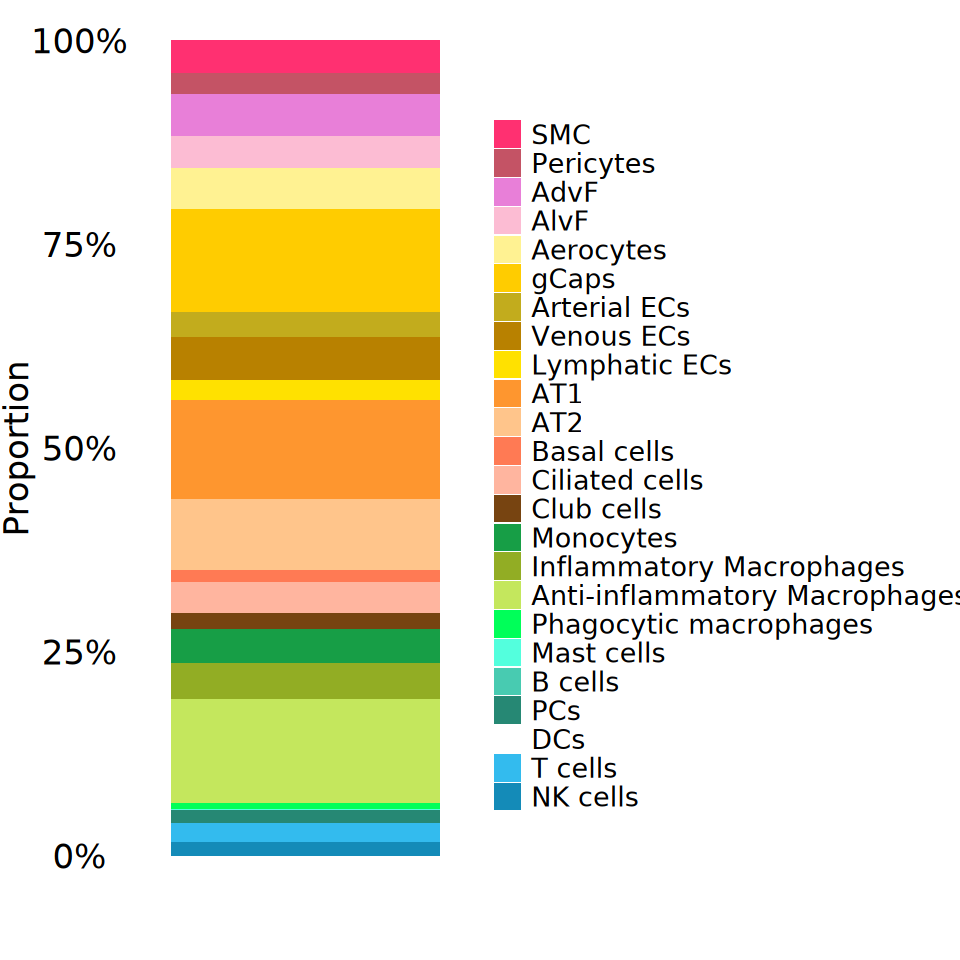

In [42]:
options(repr.plot.width = 8, repr.plot.height = 8, warn = -1)

p <- se_filtered@meta.data %>%
    mutate(annotation = factor(annotation, levels = names(palette))) %>%
    ggplot(aes(x = "", fill = annotation)) + 
        geom_bar(position = "fill") +
        labs(x = "", y = "Proportion") + 
        scale_y_continuous(labels = scales::percent_format()) +
        scale_fill_manual(values = palette, breaks = names(palette), limits = names(palette), name = "") + 
        theme_void() + 
        theme(axis.text = element_text(color = "black", size = 20),
              axis.title = element_text(color = "black", size = 20), 
              axis.title.y = element_text(angle = 90),
              legend.text = element_text(size = 16), 
              legend.title = element_text(size = 16),
              legend.position = "right") +
        guides(fill = guide_legend(ncol = 1))
ggsave("~/SP-COVID/snRNAseq/0-annotation/out/plots/barplot.svg", plot = p, device = svglite)
print(p)

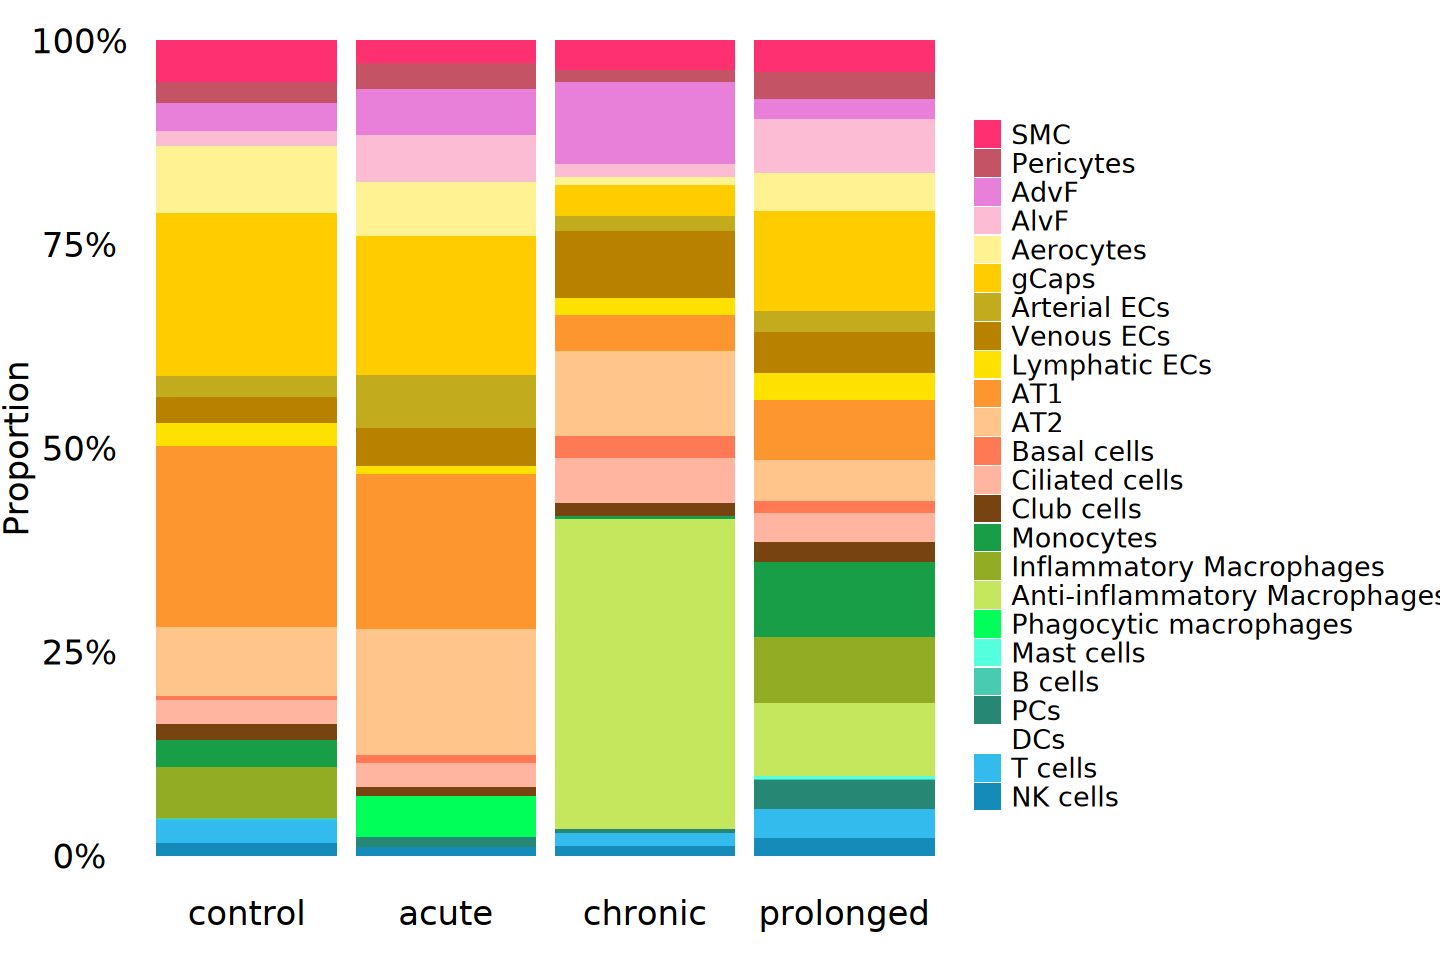

In [43]:
options(repr.plot.width = 12, repr.plot.height = 8, warn = -1)

p <- se_filtered@meta.data %>%
    mutate(condition = recode(condition, "akut" = "acute"),
           condition = factor(condition, levels = c("control", "acute", "chronic", "prolonged")),
           annotation = factor(annotation, levels = names(palette))) %>%
    ggplot(aes(x = condition, fill = annotation)) + 
        geom_bar(position = "fill") +
        labs(x = "", y = "Proportion") + 
        scale_y_continuous(labels = scales::percent_format()) +
        scale_fill_manual(values = palette, breaks = names(palette), limits = names(palette), name = "") + 
        theme_void() + 
        theme(axis.text = element_text(color = "black", size = 20),
              axis.title = element_text(color = "black", size = 20), 
              axis.title.y = element_text(angle = 90),
              legend.text = element_text(size = 16), 
              legend.title = element_text(size = 16),
              legend.position = "right") +
        guides(fill = guide_legend(ncol = 1))
ggsave("~/SP-COVID/snRNAseq/0-annotation/out/plots/barplot_condition.svg", plot = p, device = svglite, width = 12, height = 8)
print(p)

## Save data

In [44]:
out_dir <- "~/SP-COVID/snRNAseq/0-annotation/out"

"{out_dir}/se_annot_filtered.rds" %>%
    glue::glue() %>%
    here::here() %>%
  saveRDS(object = se_filtered, file = .)

"{out_dir}/se_annot.rds" %>%
    glue::glue() %>%
    here::here() %>%
  saveRDS(object = se, file = .)

## Session information

In [45]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] future_1.70.0      svglite_2.2.2      igraph_2.2.2       Seurat_5.4.0      
 [5] SeuratObject_5.3.0 sp_2.2-1           patchwork_1.3.2    lubridate_1.9.5   
 [9] forcats_1.0.1      stringr_1.6.0      dplyr_